In [1]:
from pathlib import Path
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
# Rutas base: ajusta a tu sistema
base_main = Path("/Volumes/Esteban_SSD/Maestría/MITgcm/verification")

scenarios = {
    'realistic': base_main / 'BayIW_Rectan',
    'linear'   : base_main / 'BayIW_Rectan_linear',
    '2layer'   : base_main / 'BayIW_Rectan_2layer',
    # añade más aquí si quieres
}

In [2]:

"""
Script para analizar y comparar salidas de MITgcm
con bahía y sin bahía, empleando netCDF vía MITgcmutils / xarray.
 
Incluye:
1. Lectura de archivos netCDF con MITgcmutils.
2. Funciones para graficar:
   - Batimetría (vista completa y zoom).
   - Velocidades superficiales y verticales.
   - Diferencias entre "con bahía" y "sin bahía".
   - Corte vertical (perfil) de la velocidad vertical.
3. Funciones para generar animaciones de variables (Eta, W, etc.).

Requerimientos:
- numpy, matplotlib, cmocean, MITgcmutils, xarray, seaborn
"""

import numpy as np
import matplotlib.pyplot as plt
import cmocean as cmo
import seaborn as sns
import xarray as xr
import MITgcmutils as MIT
import gsw 

from matplotlib.animation import FuncAnimation

# Ajustar el estilo general de seaborn (opcional)
sns.set_context('notebook')

# --------------------------------------------------------------------
# 1. Lectura de archivos netCDF (con y sin bahía) y carga de variables
# --------------------------------------------------------------------

def cargar_datos_mitgcm(outdir_bay: Path, outdir_nobay: Path,
                        use_wildcard: bool = False):
    """Carga archivos netCDF (bay / nobay) y devuelve un diccionario."""
    pattern = 'state.*.t*.nc' if use_wildcard else 'state.0000002880.t*.nc'

    nc_bay   = MIT.mnc_files(str(outdir_bay   / pattern))
    gr_bay   = MIT.mnc_files(str(outdir_bay   / 'grid.t*.nc'))
    nc_nobay = MIT.mnc_files(str(outdir_nobay / pattern))

    time = nc_bay.variables['T'][:]          # segundos
    return {
        'nc_bay': nc_bay,
        'nc_nobay': nc_nobay,
        'gr_bay': gr_bay,
        'time': time
    }

# --------------------------------------------------------------------
# 2. Helper: interpolate velocity components to cell centres
# --------------------------------------------------------------------

def unstagger_uv(ugrid, vgrid):
    """
    Interpolate U (on x-faces) and V (on y-faces) to cell centres.

      ugrid : (t, z, y , xp1)
      vgrid : (t, z, yp1, x)

    Returns
    -------
    u, v : (t, z, y, x)   # same shape, centred fields
    """
    u = 0.5 * (ugrid[..., :-1] + ugrid[..., 1:])        # (t,z,y,x)
    v = 0.5 * (vgrid[..., :-1, :] + vgrid[..., 1:, :])  # (t,z,y,x)
    return u, v


def unstagger_w(wgrid):
    """
    Interpolate W (on z-faces) to the vertical centre of each cell.

      wgrid : (t, zp1, y, x)

    Returns
    -------
    w : (t, z, y, x)   # z = zp1-1
    """
    return 0.5 * (wgrid[:, :-1, ...] + wgrid[:, 1:, ...])

# --------------------------------------------------------------------
# 2. Función para graficar la batimetría en vista completa y zoom
# --------------------------------------------------------------------
def plot_bathy_full_zoom_with_sts(gr, X_sym=150, Y_cut=420, 
                                           i_sta=179, j_sta=466):
    """
    Dibuja la batimetría (depth) en 2 subplots:
    1) Vista completa
    2) Zoom en la región de interés
    
    y superpone un marcador en (j_st, i_st).
    """
    # Extraer variables de gr
    depth = gr.variables['Depth'][:]
    mask = np.ma.getmask(np.ma.masked_values(depth, 0))  # mascara donde depth=0
    XC = gr.variables['XC'][:]
    YC = gr.variables['YC'][:]

    # Definir límites para la escala de color
    vmin = np.nanmin(-depth)
    vmax = np.nanmax(-depth)

    # Figura con 2 subplots
    fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

    # Subplot 1 (vista completa)
    pc1 = ax1.contourf(
        XC[0, :]/1000,
        YC[:, 0]/1000,
        np.ma.masked_array(-depth, mask=mask),
        cmap=cmo.cm.deep_r,
        vmin=vmin, vmax=vmax
    )
    ax1.set_aspect('equal')
    ax1.set_facecolor('tan')
    ax1.set_title('Bathymetry (whole domain)')
    ax1.set_xlabel('X (km)')
    ax1.set_ylabel('Y (km)')
    
    # Marcar la estación también en la vista completa (opcional)
    x_sta = XC[j_sta, i_sta]
    y_sta = YC[j_sta, i_sta]
    x_sta /= 1000  # Convertir a km
    y_sta /= 1000  # Convertir a km
    #Estacion b
    x_stb = XC[245, 30]
    y_stb = YC[245, 30]
    x_stb /= 1000  # Convertir a km
    y_stb /= 1000  # Convertir a km
    ax1.plot(x_stb, y_stb, 'bo', markersize=6, label='Station b')
    ax1.plot(x_sta, y_sta, 'ro', markersize=6, label='Station a')
    ax1.legend()

    # Subplot 2 (zoom)
    X_axis_idx = len(XC[0, :]) // 2  # Centro aproximado en X
    pc2 = ax2.contourf(
        XC[0, X_axis_idx - X_sym : X_axis_idx + X_sym]/1000,
        YC[-Y_cut:, 0]/1000,
        np.ma.masked_array(
            -depth[-Y_cut:, X_axis_idx - X_sym : X_axis_idx + X_sym],
            mask=mask[-Y_cut:, X_axis_idx - X_sym : X_axis_idx + X_sym]
        ),
        cmap=cmo.cm.deep_r,
        vmin=vmin, vmax=vmax
    )
    ax2.set_aspect('equal')
    ax2.set_facecolor('tan')
    ax2.set_title('Bathymetry (zoom)')

    # Marcar la estación en el zoom (solo se verá si cae dentro de esos recortes)
    ax2.plot(x_sta, y_sta, 'ro', markersize=8)
    ax2.text(x_sta, y_sta, "Estación", color="white", fontsize=8,
             ha='left', va='bottom')

    # Barra de color global
    cbar = fig.colorbar(pc1, ax=[ax1, ax2], label='depth (m)')
    #plt.tight_layout()
    plt.show()



# --------------------------------------------------------------------
# 3. Funciones para graficar variables instantáneas (U, V, W, Eta, etc.)
# --------------------------------------------------------------------
def plot_variable_2d(var2d, X, Y, mask, time_val, varname="Var", units="", 
                     cmap=cmo.cm.balance, vmin=None, vmax=None):
    """
    Grafica una variable 2D (ej. W, Eta) en un pcolormesh, con contorno de la máscara.
    Parámetros
    ----------
    var2d    : np.ndarray 2D con la variable a graficar
    X, Y     : coordenadas (2D o 1D) del dominio
    mask     : máscara para contornear la región de tierra (u otras)
    time_val : valor de tiempo (s, o lo que sea) para el título
    varname  : nombre de la variable (para el título)
    units    : unidades (ej. m/s)
    cmap     : colormap
    vmin,vmax: límites de color
    """
    fig, ax = plt.subplots(figsize=(10, 6))
    mesh = ax.pcolormesh(X, Y, var2d, cmap=cmap, vmin=vmin, vmax=vmax)
    fig.colorbar(mesh, ax=ax, label=f"{varname} ({units})")

    # Contorno de la máscara
    ax.contour(X, Y, mask, colors='black', linewidths=2, linestyles='--')

    # Etiquetas y título
    ax.set_title(f"{varname} a {time_val / 3600:.2f} h")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_aspect('equal')
    plt.tight_layout()
    plt.show()



In [3]:
def process_mnc_scenario(name: str, base_dir: Path, color: str):
    """Lee los .mnc de bay/nobay y devuelve un diccionario con los handlers."""
    print(f'► Procesando mnc de escenario: {name}')

    bay_dir   = base_dir / 'run_expand'         / 'mnc_00*'
    nobay_dir = base_dir / 'run_expand_nobay'   / 'mnc_00*'

    data = cargar_datos_mitgcm(bay_dir, nobay_dir, use_wildcard=True)
    nc_bay = data['nc_bay']
    nc_nobay = data['nc_nobay']
    gr_bay = data['gr_bay']
    time = data['time']

    return nc_bay, nc_nobay, gr_bay, time

In [7]:
name= '2layer'
base_dir = scenarios[name]

bay_dir   = base_dir / 'run_expand'         / 'mnc_00*'
nobay_dir = base_dir / 'run_expand_nobay'   / 'mnc_00*'


data = cargar_datos_mitgcm(bay_dir, nobay_dir, use_wildcard=True)
nc_bay = data['nc_bay']
nc_nobay = data['nc_nobay']
gr_bay = data['gr_bay']
time = data['time']

In [10]:
XC = gr_bay.variables['XC'][0,:]
YC = gr_bay.variables['YC'][:,0]
print (f"XC shape: {XC.shape}, YC shape: {YC.shape}")

XC shape: (272,), YC shape: (320,)


In [12]:
eje_bay = len(XC[:]) // 2 
radio = eje_bay-30 
print(f"eje_bay: {eje_bay}, radio: {radio}")

eje_bay: 136, radio: 106


In [ ]:
## Definimos las tres estaciones de interés: Con un radio 100 celdas
# --------------------------------------------------------------------
# Estación a
eje_bay = len(XC[:]) // 2  # Centro aproximado en X
radio = 100  # Radio de la estación en celdas
eje_y_ocean = 245
#

# Estación a
i_st_b, j_st_b = eje_bay-radio, eje_y_ocean
# Estación b
i_st_c, j_st_c = eje_bay-radio, eje_y_ocean
# Estación c
i_st_c, j_st_c = eje_bay, eje_y_ocean -radio

In [4]:
def plot_bathy_full_zoom_with_stations(
    gr,
    stations: list,
    X_sym: int = 150,
    Y_cut: int = 420,
):
    """
    Dibuja la batimetría (depth) en 2 subplots:
      1) Vista completa
      2) Zoom en la región de interés
    
    Y superpone un marcador para cada estación definida en `stations`.
    Cada estación se define como (i, j, 'label', 'color').
    """
    import numpy as np
    import cmocean as cmo
    import matplotlib.pyplot as plt
    import matplotlib.patheffects as pe

    # --- 1) Extraer variables de la grilla ---
    depth = gr.variables['Depth'][:]            # shape (ny, nx)
    mask2d = np.ma.getmask(np.ma.masked_values(depth, 0))
    XC2d  = gr.variables['XC'][:, :]            # shape (ny, nx)
    YC2d  = gr.variables['YC'][:, :]            # shape (ny, nx)

    vmin = np.nanmin(-depth)
    vmax = np.nanmax(-depth)

    # --- 2) Crear figura y ejes ---
    fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

    # ==== Subplot 1: vista completa ====
    pc1 = ax1.contourf(
        XC2d / 1000.0,
        YC2d / 1000.0,
        np.ma.masked_array(-depth, mask2d),
        cmap=cmo.cm.deep_r,
        vmin=vmin, vmax=vmax,
    )
    ax1.set_aspect('equal')
    ax1.set_facecolor('tan')
    ax1.set_title('Bathymetry (whole domain)')
    ax1.set_xlabel('X (km)')
    ax1.set_ylabel('Y (km)')

    # Marcar todas las estaciones en la vista completa
    for (i_st, j_st, label, color) in stations:
        x_st = XC2d[j_st, i_st] / 1000.0
        y_st = YC2d[j_st, i_st] / 1000.0
        ax1.plot(x_st, y_st,
                 marker='o',
                 markersize=6,
                 color=color,
                 label=f'Estación {label}'
        )
    ax1.legend(loc='upper right', fontsize='small')

    # ==== Subplot 2: zoom ====
    ny, nx = depth.shape
    centro_x = nx // 2

    x_min = max(0, centro_x - X_sym)
    x_max = min(nx, centro_x + X_sym)
    y_min = max(0, ny - Y_cut)
    y_max = ny

    pc2 = ax2.contourf(
        XC2d[y_min:y_max, x_min:x_max] / 1000.0,
        YC2d[y_min:y_max, x_min:x_max] / 1000.0,
        np.ma.masked_array(
            -depth[y_min:y_max, x_min:x_max],
            mask2d[y_min:y_max, x_min:x_max]
        ),
        cmap=cmo.cm.deep_r,
        vmin=vmin, vmax=vmax,
    )
    ax2.set_aspect('equal')
    ax2.set_facecolor('tan')
    ax2.set_title('Bathymetry (zoom)')

    # Marcar todas las estaciones en el zoom (solo si caen dentro del recorte)
    for (i_st, j_st, label, color) in stations:
        # Checar si está dentro de [x_min, x_max) × [y_min, y_max)
        if (x_min <= i_st < x_max) and (y_min <= j_st < y_max):
            x_st = XC2d[j_st, i_st] / 1000.0
            y_st = YC2d[j_st, i_st] / 1000.0
            ax2.plot(
                x_st, y_st,
                marker='o',
                markersize=8,
                color=color,
                markeredgecolor='black'
            )
            ax2.text(
                x_st, y_st,
                f"{label}",
                color="white",
                fontsize=8,
                ha='left',
                va='bottom',
                path_effects=[
                    pe.Stroke(linewidth=1, foreground='black'),
                    pe.Normal()
                ]
            )

    # Colorbar compartida
    fig.colorbar(pc1, ax=[ax1, ax2], label='depth (m)')
    #plt.tight_layout()
    plt.show()


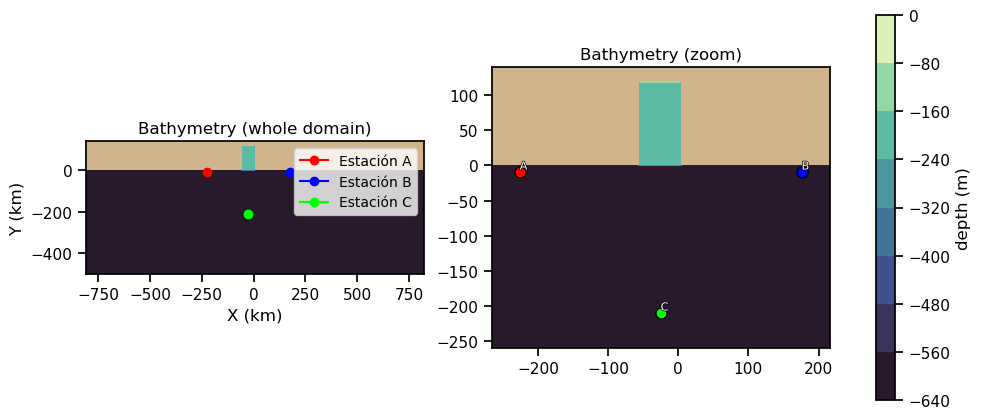

In [17]:
ny, nx = gr_bay.variables['XC'].shape  # dimensiones de la grilla
i_centro = nx // 2      # índice central en X
j_centro = 245          # por ejemplo, eje Y “central”

radio = 100             # cuántas celdas desplazar para estaciones A/B/C

# Estación A: 100 celdas a la izquierda del centro, color rojo
iA, jA = i_centro - radio, j_centro

# Estación B: 100 celdas a la derecha del centro, color azul
iB, jB = i_centro + radio, j_centro

# Estación C: misma X central, pero 100 celdas más al norte, color verde lima
iC, jC = i_centro, j_centro - radio

stations = [
    (iA, jA, 'A', 'red'),
    (iB, jB, 'B', 'blue'),
    (iC, jC, 'C', 'lime'),
]

plot_bathy_full_zoom_with_stations(
    gr       = gr_bay,
    stations = stations,
    X_sym    = 120,
    Y_cut    = 200,
)

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import detrend

def analizar_ssh_y_espectro_multistation(
    nc_bay,
    nc_nobay,
    time,
    stations: list,
    tmin_horas: float = 27.0
):
    """
    Calcula y grafica la diferencia de altura superficial (Eta)
    entre configuraciones 'con bahía' y 'sin bahía' en varias estaciones,
    sobre la misma figura para la serie temporal y otra para la FFT.

    Ahora espera `stations` como lista de tuplas (i_st, j_st, etiqueta, color),
    por ejemplo: [(iA, jA, 'A', 'red'), (iB, jB, 'B', 'blue'), (iC, jC, 'C', 'lime')]

    Parámetros
    ----------
    nc_bay : objeto netCDF (MITgcmutils)
        Contiene la variable 'Eta' para el caso con bahía.
    nc_nobay : objeto netCDF (MITgcmutils)
        Contiene la variable 'Eta' para el caso sin bahía.
    time : array-like
        Vector de tiempo, en segundos.
    stations : list of tuples
        Lista de estaciones, cada una dada como (i_st, j_st, etiqueta, color).
    tmin_horas : float
        Tiempo mínimo (en horas) a partir del cual se recorta la señal.
    """

    # 1) Convertimos el vector de tiempo a numpy y calculamos índice de corte
    t = np.array(time, dtype=float)
    tmin_seg = tmin_horas * 3600.0
    idx_start = np.where(t >= tmin_seg)[0][0] if np.any(t >= tmin_seg) else 0

    # 2) Recortamos el tiempo y convertimos a horas para graficar
    t_cut = t[idx_start:]
    t_cut_horas = t_cut / 3600.0

    # 3) Figura 1: Serie temporal
    plt.figure(figsize=(7, 5))

    # 4) Diccionarios para almacenar resultados de FFT
    espectros = {}
    frec_cphs = None

    # 5) Bucle principal: ahora desempacamos (i_st, j_st, label, color)
    for (i_st, j_st, label, color) in stations:
        # 5.1) Extraer valores de 'Eta' en la estación (toda la serie)
        eta_bay   = np.array(nc_bay.variables['Eta'][:, j_st, i_st], dtype=float)
        eta_nobay = np.array(nc_nobay.variables['Eta'][:, j_st, i_st], dtype=float)

        # 5.2) Recortar cada señal a partir de idx_start
        eta_b_cut = eta_bay[idx_start:]
        eta_n_cut = eta_nobay[idx_start:]

        # 5.3) Diferencia de altura superficial
        eta_diff_cut = eta_b_cut - eta_n_cut

        # 5.4) Graficar la serie temporal (t_cut_horas vs. eta_diff_cut)
        plt.plot(
            t_cut_horas,
            eta_diff_cut,
            label=f'Estación {label}',
            color=color
        )

        # 5.5) Preparar señal para FFT
        eta_detrend = detrend(eta_diff_cut)               # quitar tendencia
        dt = t_cut[1] - t_cut[0] if len(t_cut) > 1 else 1.0
        fs = 1.0 / dt

        # 5.6) Cálculo de FFT unidireccional
        N = len(eta_detrend)
        Y = np.fft.rfft(eta_detrend)
        freqs = np.fft.rfftfreq(N, d=dt)

        # 5.7) PSD (forma simple)
        PSD = (1.0 / N**2) * np.abs(Y)**2

        # 5.8) Convertir frecuencia a ciclos/hora
        freq_cph = freqs * 3600.0

        # 5.9) Almacenar espectro para graficar más tarde
        espectros[label] = (freq_cph, PSD)

        # 5.10) Guardar eje de frecuencias si aún no existe
        if frec_cphs is None:
            frec_cphs = freq_cph

    # --- Terminamos la figura de la serie temporal ---
    plt.xlabel(f'Tiempo (horas) desde {tmin_horas} h')
    plt.ylabel('Δ Eta (m)')
    plt.title(f'Diferencia Eta (bahía - sin bahía)\nDesde {tmin_horas} h')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # --- Figura 2: Espectros en la misma figura ---
    plt.figure(figsize=(7, 5))

    for (i_st, j_st, label, color) in stations:
        freq_cph, PSD = espectros[label]
        plt.plot(
            freq_cph,
            PSD,
            label=f'Estación {label}',
            color=color
        )

    plt.xlim(0, 0.8)  # ajusta según necesites
    plt.xlabel('Frecuencia (ciclos/hora)')
    plt.axvline(0.303356, color='k', linestyle='--', linewidth=0.5, label='Frecuencia de seiche')
    plt.ylabel('PSD [m²/cph]')
    plt.title(f'Espectro ΔEta (Varias estaciones, desde {tmin_horas} h)')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


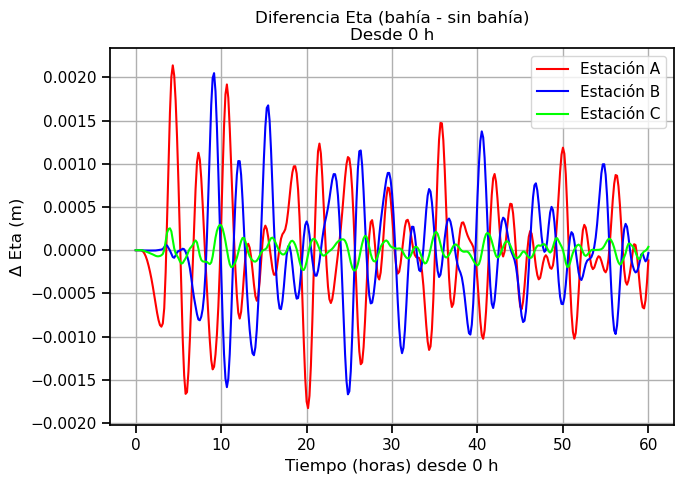

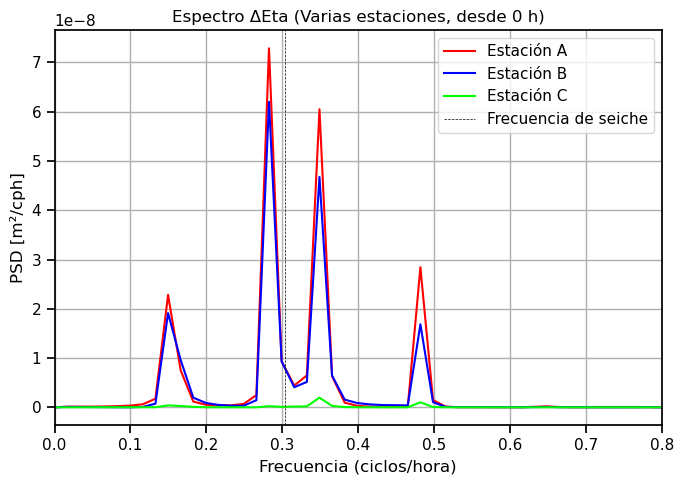

In [19]:
analizar_ssh_y_espectro_multistation(
    nc_bay=nc_bay,
    nc_nobay=nc_nobay,
    time=time,
    stations=stations,
    tmin_horas=0
)

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import detrend
import os

def analizar_w_y_espectro_multistation_dosprof(
    nc_bay,
    nc_nobay,
    time,
    stations: list,
    depth_levels: list,
    *,
    tmin_horas: float = 0.0,
    save_dir: str = None,
    escenario_tag: str = "escenario",
    formato: str = "npz",
    var_name: str = "W",
    depth_coord_name: str = "Z"
):
    """
    Diferencia de velocidad vertical (W_bay - W_nobay) en DOS profundidades
    para VARIAS estaciones, y su FFT.

    Ahora `stations` debe ser lista de tuplas (i_st, j_st, etiqueta, color).
    Ejemplo: [(iA, jA, 'A', 'red'), (iB, jB, 'B', 'blue'), (iC, jC, 'C', 'lime')].

    depth_levels: lista con EXACTAMENTE dos profundidades deseadas;
                  pueden ser valores en metros (negativos o positivos)
                  o índices enteros directos.

    El plot de series temporales muestra, para cada estación:
      - Línea sólida  = profundidad más superficial
      - Línea punteada = profundidad más profunda
      Ambas con el color que se indicó en `stations`.

    Parámetros
    ----------
    nc_bay / nc_nobay : handlers netCDF de MITgcm (MITgcmutils u xarray),
                        que contienen la variable var_name en dimensiones 
                        (time, z, y, x).
    time              : vector de tiempo en segundos (1D).
    stations          : lista de tuplas (i_st, j_st, etiqueta, color).
    depth_levels      : lista de dos profundidades, p.ej. [100, 400] (m) 
                        o índices verticales [k0, k1].
    tmin_horas        : hora mínima para comenzar el recorte (en horas).
    save_dir          : carpeta donde se guardan archivos .npz o .npy.
    escenario_tag     : prefijo para el nombre de los archivos.
    formato           : "npz" o "npy".
    var_name          : nombre de la variable vertical en el netCDF (p.ej. "W").
    depth_coord_name  : nombre de la coordenada vertical en el netCDF (p.ej. "Z").
    """

    # ——————————— 1) Tiempo y recorte ————————————
    t = np.asarray(time, dtype=float)
    tmin_seg = tmin_horas * 3600.0
    idx0 = np.where(t >= tmin_seg)[0][0] if np.any(t >= tmin_seg) else 0
    t_cut = t[idx0:]
    t_h = t_cut / 3600.0  # en horas

    # —————————— 2) Niveles de profundidad (índices) ——————————
    # Obtenemos el arreglo de profundidades (Z) en metros (suele ser negativo hacia abajo).
    z_vals = np.asarray(nc_bay.variables[depth_coord_name][:], dtype=float)
    z_dim = len(z_vals)

    dep_idx = []
    dep_lbl = []
    # Convertir cada valor de depth_levels a índice de capa
    for d in depth_levels:
        if isinstance(d, int) and 0 <= d < z_dim:
            k = d
        else:
            # Buscamos el nivel cuya profundidad (valor de zi) esté más cerca de |d|
            # (z_vals son negativos para profundidades positivas).
            # Por ejemplo, si d=100, buscamos zi ≈ -100.
            k = int(np.argmin(np.abs(z_vals + abs(d))))
        dep_idx.append(k)
        dep_lbl.append(f"{abs(z_vals[k]):.0f} m")

    if len(dep_idx) != 2:
        raise ValueError("depth_levels debe contener exactamente dos niveles")

    # Ordenamos para saber cuál es más superficial vs. cuál más profundo:
    # Profundidad “menor en |z|” (menos negativa) = más superficial.
    # Profundidad “mayor en |z|” (más negativa)  = más profunda.
    # Creamos una lista de tuplas (k, etiqueta, estilo), ordenada de superficial->profundo.
    niveles_ordenados = []
    # emparejamos cada índice con su etiqueta correspondiente
    for k, lbl in zip(dep_idx, dep_lbl):
        niveles_ordenados.append((k, lbl))
    # ordenamos según |z_vals[k]| (menor primero)
    niveles_ordenados.sort(key=lambda item: abs(z_vals[item[0]]))

    # Después de ordenar, asignamos estilos:
    #   niveles_ordenados[0] -> superficial  -> línea sólida ("-")
    #   niveles_ordenados[1] -> profundo     -> línea punteada (":")
    estilo_por_nivel = {
        niveles_ordenados[0][0]: "-",  # índice superficial
        niveles_ordenados[1][0]: ":",  # índice profundo
    }

    espectros = {}  # dict[(est_label, k)] = (freq_cph, PSD)

    # —————————— 3) Figura: serie temporal (todas las estaciones juntas) ——————————
    plt.figure(figsize=(8, 5))
    for (i_st, j_st, label, color) in stations:
        for k in dep_idx:
            # extraer W en (t, k, j, i)
            w_b = np.array(nc_bay.variables[var_name][:, k, j_st, i_st], dtype=float)
            w_n = np.array(nc_nobay.variables[var_name][:, k, j_st, i_st], dtype=float)
            w_diff = w_b[idx0:] - w_n[idx0:]

            # estilo según nivel
            ls = estilo_por_nivel[k]
            # etiqueta de leyenda: "A @ 100 m" o similar
            leyenda = f"{label} @ {abs(z_vals[k]):.0f} m"

            plt.plot(
                t_h,
                w_diff,
                color=color,
                linestyle=ls,
                linewidth=1.2,
                label=leyenda
            )

            # Calcular FFT y guardar en dict para la 2ª figura
            w_dt = detrend(w_diff)
            dt = t_cut[1] - t_cut[0] if len(t_cut) > 1 else 1.0
            N = len(w_dt)
            freqs = np.fft.rfftfreq(N, d=dt)
            PSD = (np.abs(np.fft.rfft(w_dt)) ** 2) / N**2
            espectros[(label, k)] = (freqs * 3600.0, PSD)

            # Si se pide guardar en disco, lo hacemos aquí
            if save_dir:
                os.makedirs(save_dir, exist_ok=True)
                prof = int(abs(z_vals[k]))
                fn = os.path.join(
                    save_dir,
                    f"{escenario_tag}_Wdiff_{label}_{prof}m.{formato}"
                )
                if formato == "npz":
                    np.savez_compressed(
                        fn,
                        t_h=t_h,
                        Wdiff=w_diff,
                        freq_cph=espectros[(label, k)][0],
                        PSD=espectros[(label, k)][1]
                    )
                elif formato == "npy":
                    np.save(fn, {
                        "t_h": t_h,
                        "Wdiff": w_diff,
                        "freq_cph": espectros[(label, k)][0],
                        "PSD": espectros[(label, k)][1]
                    })
                else:
                    raise ValueError("formato debe ser 'npz' o 'npy'")

    plt.xlabel("Tiempo (h)")
    plt.ylabel("ΔW (m s⁻¹)")
    plt.title("ΔW (bahía – sin-bahía) en varias estaciones\n" +
              f"Desde {tmin_horas} h, profundidades: {dep_lbl[0]} & {dep_lbl[1]}")
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize="small")
    plt.tight_layout()
    plt.show()

    # ————————— Figura 2: espectros (todas las estaciones juntas) —————————
    plt.figure(figsize=(8, 5))
    #plt.yscale("log", base=10)
    for (i_st, j_st, label, color) in stations:
        for k in dep_idx:
            f_cph, Psd = espectros[(label, k)]
            prof = abs(z_vals[k])
            ls = estilo_por_nivel[k]
            plt.plot(
                f_cph,
                Psd,
                color=color,
                linestyle=ls,
                linewidth=1.3,
                label=f"{label} @ {prof:.0f} m"
            )

    plt.xlim(0, 0.8)
    plt.axvline(0.303356, ls="--", lw=0.8, color="k", label="Seiche")
    plt.xlabel("Frecuencia (ciclos/hora)")
    plt.ylabel("PSD [(m s⁻¹)² / cph]")
    plt.title("Espectro de ΔW en varias estaciones")
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize="small", ncol=2)
    plt.tight_layout()
    #plt.xlim(0.1, 0.8)
    #plt.ylim(min(10e-10, np.min([Psd for _, Psd in espectros.values()])), 1e-2)
    plt.show()

    return {"t_h": t_h, "espectros": espectros}


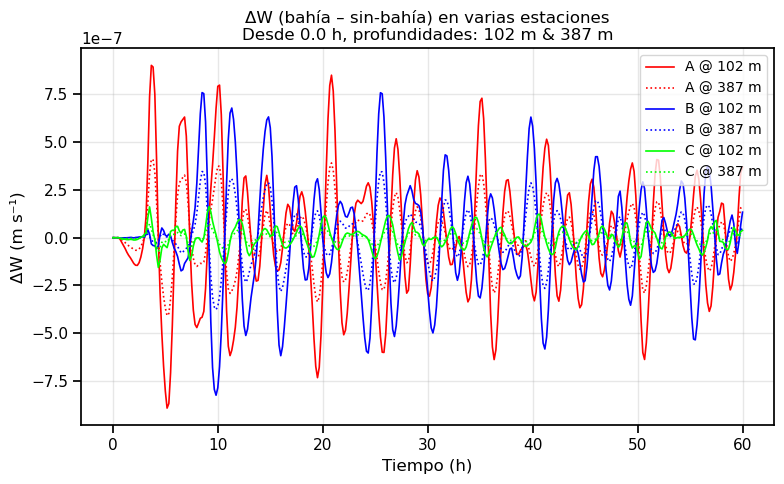

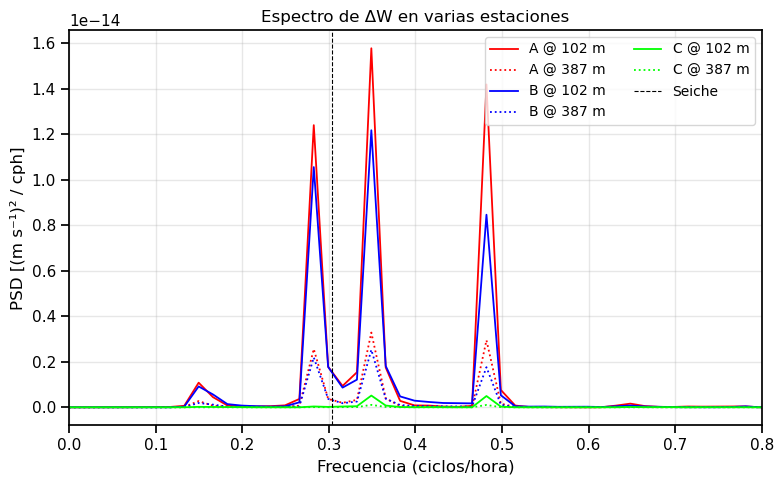

In [40]:
depth_levels = [100, 400]  # en metros (interpretará como |z|=100 y |z|=400)
resultados = analizar_w_y_espectro_multistation_dosprof(
    nc_bay        = nc_bay,
    nc_nobay      = nc_nobay,
    time          = time,
    stations      = stations,
    depth_levels  = depth_levels,
    tmin_horas    = 0.0,             # o el valor que quieras
    save_dir      = "salidas_Wdiff", # carpeta donde guardar `.npz`, si la deseas
    escenario_tag = "miEscenario",
    formato       = "npy"
)

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import detrend
import os

def analizar_w_y_espectro_multistation_dosprof(
    nc_bay,
    nc_nobay,
    time,
    stations: list,
    depth_levels: list,
    *,
    tmin_horas: float = 0.0,
    save_dir: str = None,
    escenario_tag: str = "escenario",
    formato: str = "npz",
    var_name: str = "W",
    depth_coord_name: str = "Z"
):
    # 1) Tiempo y recorte
    t = np.asarray(time, float)
    tmin_seg = tmin_horas * 3600.0
    idx0 = np.where(t >= tmin_seg)[0][0] if np.any(t >= tmin_seg) else 0
    t_cut = t[idx0:]
    t_h = t_cut / 3600.0

    # 2) Profundidades -> índices
    z_vals = np.asarray(nc_bay.variables[depth_coord_name][:], float)
    z_dim = len(z_vals)
    dep_idx, dep_lbl = [], []
    for d in depth_levels:
        if isinstance(d, int) and 0 <= d < z_dim:
            k = d
        else:
            k = int(np.argmin(np.abs(z_vals + abs(d))))
        dep_idx.append(k)
        dep_lbl.append(f"{abs(z_vals[k]):.0f} m")
    if len(dep_idx) != 2:
        raise ValueError("depth_levels debe tener exactamente dos niveles")

    niveles_ordenados = sorted(
        [(k, lbl) for k, lbl in zip(dep_idx, dep_lbl)],
        key=lambda x: abs(z_vals[x[0]])
    )
    estilo_por_nivel = {
        niveles_ordenados[0][0]: "-",  # superficial
        niveles_ordenados[1][0]: ":"   # profundo
    }

    espectros_dB = {}

    # 3) Serie temporal (igual que antes)
    plt.figure(figsize=(8, 5))
    for (i_st, j_st, label, color) in stations:
        for k in dep_idx:
            w_b = np.array(nc_bay.variables[var_name][:, k, j_st, i_st], float)
            w_n = np.array(nc_nobay.variables[var_name][:, k, j_st, i_st], float)
            w_diff = w_b[idx0:] - w_n[idx0:]

            ls = estilo_por_nivel[k]
            leyenda = f"{label} @ {abs(z_vals[k]):.0f} m"
            plt.plot(
                t_h,
                w_diff,
                color=color,
                linestyle=ls,
                linewidth=1.2,
                label=leyenda
            )

            # FFT y conversión a dB
            w_dt = detrend(w_diff)
            dt = t_cut[1] - t_cut[0] if len(t_cut) > 1 else 1.0
            N = len(w_dt)
            freqs = np.fft.rfftfreq(N, d=dt)
            PSD = (np.abs(np.fft.rfft(w_dt))**2) / N**2
            PSD_dB = 10.0 * np.log10(PSD + 1e-30)  # offset para no tomar log(0)
            espectros_dB[(label, k)] = (freqs * 3600.0, PSD_dB)

            # Guardado en disco (si se pide), en dB:
            if save_dir:
                os.makedirs(save_dir, exist_ok=True)
                prof = int(abs(z_vals[k]))
                fn = os.path.join(
                    save_dir,
                    f"{escenario_tag}_Wdiff_{label}_{prof}m.{formato}"
                )
                if formato == "npz":
                    np.savez_compressed(
                        fn,
                        t_h=t_h,
                        Wdiff=w_diff,
                        freq_cph=espectros_dB[(label, k)][0],
                        PSD_dB=espectros_dB[(label, k)][1]
                    )
                elif formato == "npy":
                    np.save(fn, {
                        "t_h": t_h,
                        "Wdiff": w_diff,
                        "freq_cph": espectros_dB[(label, k)][0],
                        "PSD_dB": espectros_dB[(label, k)][1]
                    })
                else:
                    raise ValueError("formato debe ser 'npz' o 'npy'")

    plt.xlabel("Tiempo (h)")
    plt.ylabel("ΔW (m s⁻¹)")
    plt.title(
        "ΔW (bahía – sin-bahía) en varias estaciones\n" +
        f"Desde {tmin_horas} h, profundidades: {dep_lbl[0]} & {dep_lbl[1]}"
    )
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize="small")
    plt.tight_layout()
    plt.show()

    # 4) Espectros en decibelios (eje Y en dB)
    plt.figure(figsize=(8, 5))
    for (i_st, j_st, label, color) in stations:
        for k in dep_idx:
            freq_cph, PSD_dB = espectros_dB[(label, k)]
            prof = abs(z_vals[k])
            ls = estilo_por_nivel[k]
            plt.plot(
                freq_cph,
                PSD_dB,
                color=color,
                linestyle=ls,
                linewidth=1.3,
                label=f"{label} @ {prof:.0f} m"
            )

    plt.xlim(0, 0.8)
    plt.axvline(0.303356, ls="--", lw=0.8, color="k", label="Seiche")
    plt.xlabel("Frecuencia (ciclos/hora)")
    plt.ylabel("PSD (dB re 1)")
    plt.title("Espectro de ΔW en varias estaciones (escala dB)")
    plt.grid(True, alpha=0.3, which="both", linestyle="--", linewidth=0.5)
    plt.legend(fontsize="small", ncol=2)
    plt.tight_layout()
    plt.show()

    return {"t_h": t_h, "espectros_dB": espectros_dB}


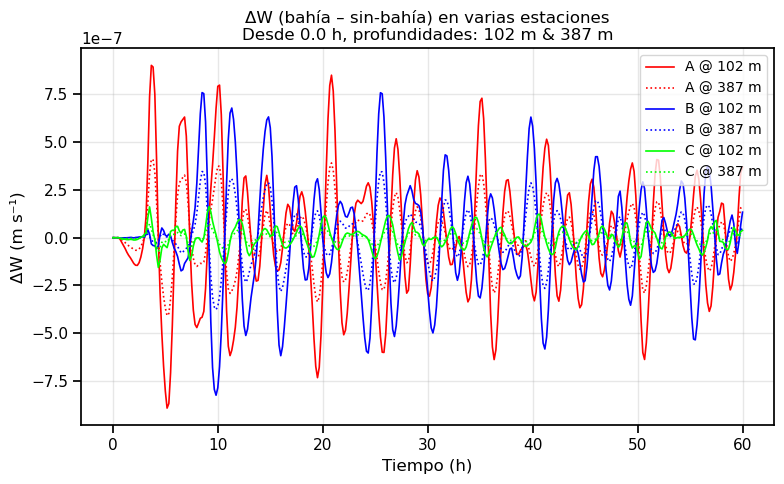

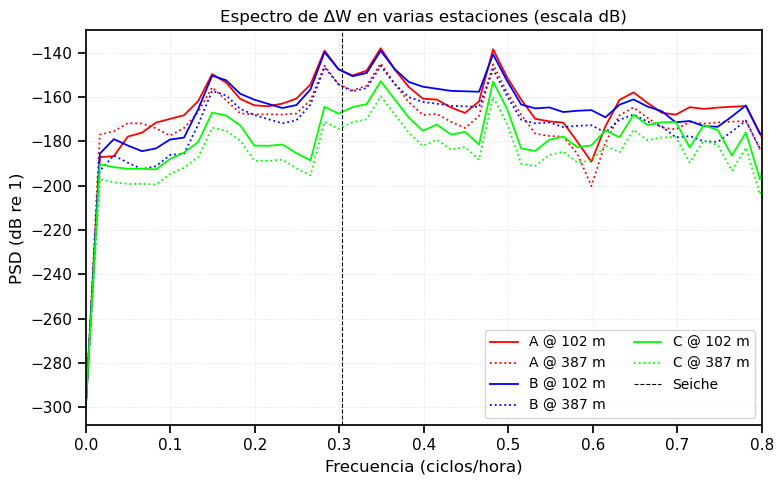

In [36]:
depth_levels = [100, 400]  # en metros (interpretará como |z|=100 y |z|=400)
resultados = analizar_w_y_espectro_multistation_dosprof(
    nc_bay        = nc_bay,
    nc_nobay      = nc_nobay,
    time          = time,
    stations      = stations,
    depth_levels  = depth_levels,
    tmin_horas    = 0.0,                     # comienzan desde t=0 h
    save_dir      = "salidas_Wdb",           # carpeta donde se guardan los .npz
    escenario_tag = "2layer",           # prefijo para los archivos de salida
    formato       = "npy",                   # “npz” o “npy”
    var_name      = "W",                     # si tu variable vertical fuera distinta
    depth_coord_name = "Z"                   # nombre de la coordenada vertical en tu netCDF
)

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import cmocean as cmo

def hovmoller_diff_multistation(
    nc_bay,
    nc_nobay,
    gr,
    stations: list,
    varname: str = 'W',
    hours_offset: float = 0.0,
    cmap = cmo.cm.balance,
    vmin: float = None,
    vmax: float = None,
    title_prefix: str = ''
):
    """
    Dibuja diagramas de Hovmöller de la diferencia (bahía – sin bahía)
    para múltiples estaciones (en paralelo).

    Parameters
    ----------
    nc_bay      : handler NetCDF (MITgcm) de la simulación con bahía.
    nc_nobay    : handler NetCDF (MITgcm) de la simulación sin bahía.
    gr          : handler NetCDF de la malla (solo se usa para extraer 'RC').
    stations    : lista de tuplas (i_st, j_st, etiqueta, color). Ejemplo:
                  [(iA, jA, 'A', 'red'), (iB, jB, 'B', 'blue'), ...]
    varname     : nombre de la variable 3-D (por defecto 'W').
    hours_offset: horas a descartar al inicio (spin-up).
    cmap        : colormap a usar en todos los subplots.
    vmin, vmax  : límites de la escala de colores. Si ambos son None,
                  se calculan automáticamente (se simetriza vmin = -vmax).
    title_prefix: texto adicional que aparecerá antes de “Hovmöller” en cada título.
    
    Returns
    -------
    fig, axes : Matplotlib figure y lista de axes, uno por estación.
    """

    # 1) Convertir vector de tiempo a horas y determinar el índice de recorte
    t_all = nc_bay.variables['T'][:] / 3600.0   # ya en horas
    if hours_offset > 0:
        idx0 = np.where(t_all >= hours_offset)[0]
        idx0 = idx0[0] if idx0.size > 0 else 0
    else:
        idx0 = 0
    t = t_all[idx0:]                            # tiempo recortado, en horas

    # 2) Extraer coordenada vertical (profundidades) una sola vez
    RC = gr.variables['RC'][:]                  # array 1D de profundidades (negativas)
    # invertimos RC abajo luego, pero por ahora lo guardamos completo

    # 3) Si vmin/vmax no fueron dados, los calculamos sobre todas las estaciones
    if (vmin is None) or (vmax is None):
        max_abs = 0.0
        for (i_st, j_st, label, color) in stations:
            # extraemos W en (time, z, j, i) para ambas corridas
            data_bay   = nc_bay.variables[varname][:, :, j_st, i_st]
            data_nobay = nc_nobay.variables[varname][:, :, j_st, i_st]
            diff_full  = data_bay - data_nobay      # (time, z)
            diff_cut   = diff_full[idx0:, :]        # recorte temporal
            m = np.nanmax(np.abs(diff_cut))
            if m > max_abs:
                max_abs = m
        vmax = max_abs
        vmin = -max_abs

    # 4) Preparamos la figura con n subplots horizontales
    n = len(stations)
    fig, axes = plt.subplots(
        nrows=1,
        ncols=n,
        figsize=(4*n, 5),
        sharey=True
    )

    # Si hay una sola estación, axes podría no ser array. Forzamos lista:
    if n == 1:
        axes = [axes]

    # 5) Loop sobre estaciones para calcular y graficar cada Hovmöller
    for ax, (i_st, j_st, label, color) in zip(axes, stations):
        # 5.1) Extraer la serie 2D (tiempo, profundo) de W para bahía y sin bahía
        data_bay   = nc_bay.variables[varname][:, :, j_st, i_st].astype(float)
        data_nobay = nc_nobay.variables[varname][:, :, j_st, i_st].astype(float)
        diff_full  = data_bay - data_nobay          # shape: (nt, nz)
        diff_cut   = diff_full[idx0:, :]            # recorte a partir de idx0

        # 5.2) Graficar pcolormesh: eje X = t, eje Y = RC, datos = diff_cut.T
        mesh = ax.pcolormesh(
            t,                     # eje X en horas
            RC,                    # eje Y en metros (negativos)
            diff_cut.T,            # (z, t) → transpuesta
            cmap=cmap,
            vmin=vmin, vmax=vmax,
            shading='auto'
        )

        # 5.3) Anotaciones y formato del subplot
        ax.set_title(f"{title_prefix} Hovmöller @ Est. {label} (i={i_st}, j={j_st})", 
                     color=color)
        ax.set_xlabel("Tiempo (h)")
        ax.invert_yaxis()  # para que la “profundidad” aumente hacia abajo

        # Si es el primer subplot, añadimos etiqueta de profundidad (eje Y)
        if ax is axes[0]:
            ax.set_ylabel("Profundidad (m)")

        # Dibujar una línea horizontal punteada en RC=0 (nivel superficial), opcional:
        ax.axhline(0.0, color='k', linestyle='--', linewidth=0.5)

    # 6) Ajustar la colorbar una sola para toda la figura
    cbar = fig.colorbar(mesh, ax=axes, orientation='vertical', fraction=0.015, pad=0.02)
    cbar.set_label(f"{varname} (bahía – sin bahía)")

    plt.tight_layout()
    plt.show()

    return fig, axes


/var/folders/md/v_9w0p656250q6gw5wc707040000gn/T/ipykernel_2159/4060406981.py:116: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


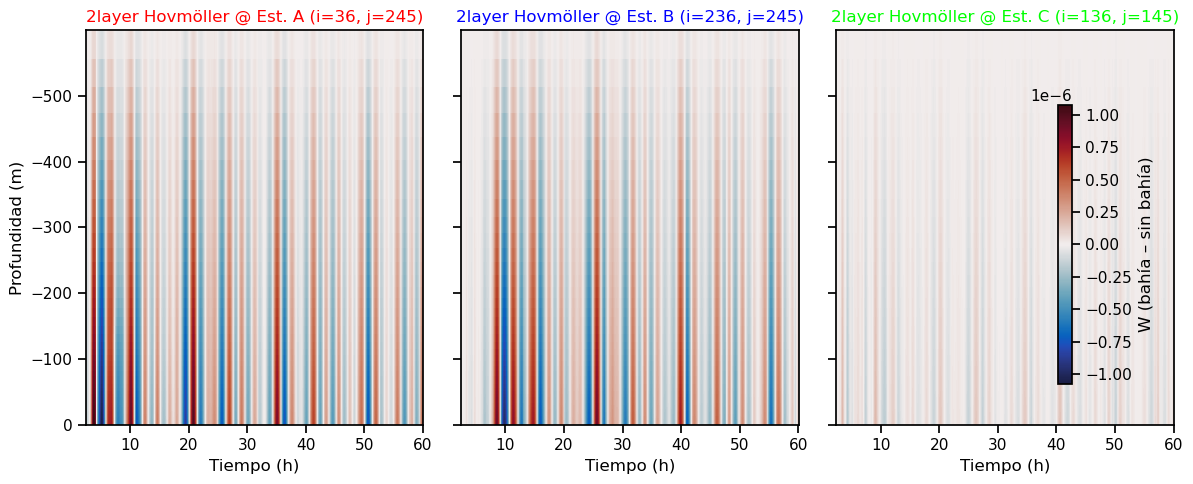

In [43]:
# Llamada a la función:
fig, axes = hovmoller_diff_multistation(
    nc_bay       = nc_bay,
    nc_nobay     = nc_nobay,
    gr           = gr_bay,
    stations     = stations,
    varname      = 'W',
    hours_offset = 2.5,             # descartar primeras 2.5 horas de spin-up
    cmap         = cmo.cm.balance,   # o cualquier otro cmap
    title_prefix = "2layer"    # texto opcional antes de “Hovmöller”
)

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import cmocean as cmo

def hovmoller_diff(
        nc_bay,
        nc_nobay,
        gr,
        station,
        varname='W',
        hours_offset=0.0,
        cmap=cmo.cm.balance,
        vmin=None,
        vmax=None,
        title_prefix=''
):
    """
    Diagrama de Hovmöller de la diferencia (bahía – sin bahía)
    en una estación puntual, con líneas punteadas
    cerca de 100 m y 400 m.

    Parámetros
    ----------
    nc_bay      : dataset MITgcm con la simulación con bahía.
    nc_nobay    : dataset MITgcm con la simulación sin bahía.
    gr          : dataset de malla (para RC).
    station     : tuple (j, i) índices de la estación.
    varname     : str   nombre de la variable 3-D (default 'W').
    hours_offset: float horas a descartar al inicio (spin-up).
    cmap        : matplotlib colormap.
    vmin, vmax  : límites de la escala; si uno es None se calcula automático
                 y se hace simétrico alrededor de 0.
    title_prefix: str   texto adicional para el título.
    """

    # 1) Índices y recorte en tiempo
    j, i = station
    t_all = nc_bay.variables['T'][:] / 3600.0   # convertir a horas
    if hours_offset > 0:
        idxs = np.where(t_all >= hours_offset)[0]
        idx0 = idxs[0] if idxs.size > 0 else 0
    else:
        idx0 = 0
    t = t_all[idx0:]  # tiempo recortado

    # 2) Serie de la variable en la estación
    data_bay   = nc_bay.variables[varname][:, :, j, i]     # shape (nt, nz)
    data_nobay = nc_nobay.variables[varname][:, :, j, i]   # shape (nt, nz)
    data_diff  = data_bay - data_nobay                      # (nt, nz)
    data_diff  = data_diff[idx0:, :]                        # recorte temporal

    # 3) Límites de color
    if (vmin is None) or (vmax is None):
        m = np.nanmax(np.abs(data_diff))
        vmax = m
        vmin = -m

    # 4) Coordenada vertical (profundidades) y búsqueda de niveles próximos a 100 m y 400 m
    RC = gr.variables['RC'][:]  # array 1D de profundidades (negativas)
    # Hallar índice cuya profundidad esté más cerca de –100 m, y de –400 m:
    idx_100 = int(np.argmin(np.abs(RC + 100.0)))
    idx_400 = int(np.argmin(np.abs(RC + 400.0)))
    z_100 = RC[idx_100]
    z_400 = RC[idx_400]

    # 5) Figura y Hovmöller
    fig, ax = plt.subplots(figsize=(9, 5))

    pcm = ax.pcolormesh(
        t,                     # eje X (tiempo en horas)
        RC,                    # eje Y (profundidad en metros negativos)
        data_diff.T,           # (nz, nt)
        cmap=cmap,
        vmin=vmin, vmax=vmax,
        shading='auto'
    )

    # 6) Dibujar líneas punteadas en los niveles hallados
    ax.hlines(
        z_100,
        xmin=t.min(),
        xmax=t.max(),
        colors='white',
        linestyles='--',
        linewidth=1.0,
        label=f"≈ 100 m (z={z_100:.1f} m)"
    )
    ax.hlines(
        z_400,
        xmin=t.min(),
        xmax=t.max(),
        colors='white',
        linestyles='--',
        linewidth=1.0,
        label=f"≈ 400 m (z={z_400:.1f} m)"
    )

    # 7) Formato adicional
    cbar = fig.colorbar(pcm, ax=ax, label=f'{varname} (bahía – sin bahía)')
    ax.set_xlabel('Tiempo (h)')
    ax.set_ylabel('Profundidad (m)')
    ax.set_title(f'{title_prefix} Hovmöller {varname}_diff — estación (j={j}, i={i})')
    #ax.invert_yaxis()  # para que profundidades “crezcan hacia abajo”

    # 8) Solo agregamos la leyenda de las líneas punteadas
    ax.legend(loc='upper right', fontsize='small')

    plt.tight_layout()
    plt.show()

    return fig, ax


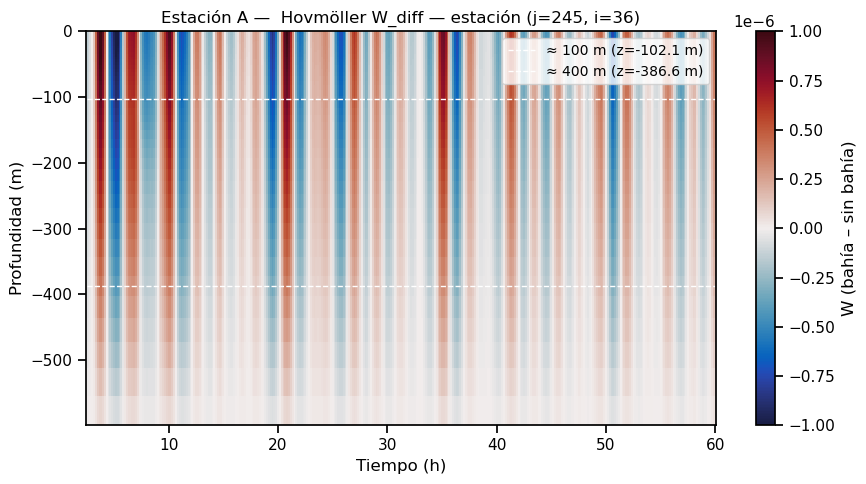

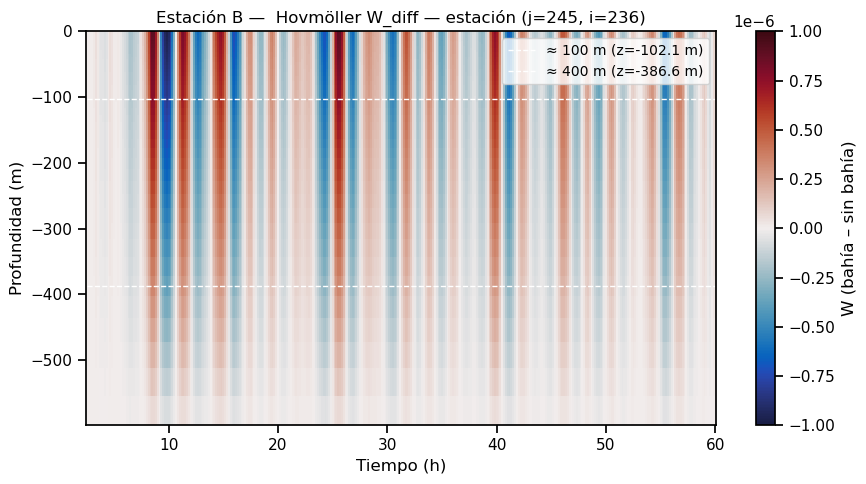

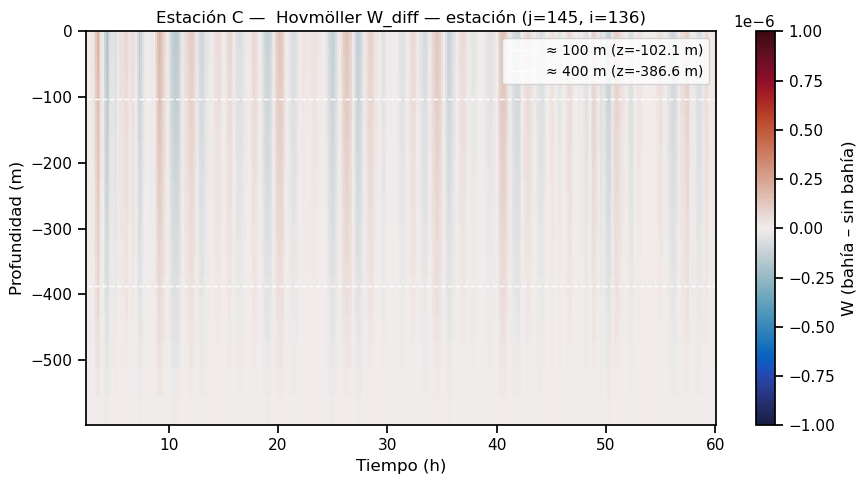

In [55]:
# Iteramos y generamos una figura independiente para cada estación
for (i_st, j_st, label, color) in stations:
    prefijo = f"Estación {label} — "

    fig, ax = hovmoller_diff(
        nc_bay       = nc_bay,
        nc_nobay     = nc_nobay,
        gr           = gr_bay,
        station      = (j_st, i_st),
        varname      = 'W',
        hours_offset = 2.5,           # por ejemplo
        cmap         = cmo.cm.balance,
        vmin         = -1e-6,
        vmax         = 1e-6,
        title_prefix = prefijo
    )

    # Reescribimos el color del título para que destaque
    ax.set_title(prefijo + f"Hovmöller W_diff", color=color)

    # Guardamos cada figura en disco
    nombre_png = f"hovmoller_{label}.png"
    fig.savefig(nombre_png, dpi=200, bbox_inches='tight')
    plt.close(fig)


=== Procesando escenario: realistic ===
  -> Graficando ΔEta (serie + espectro) para realistic


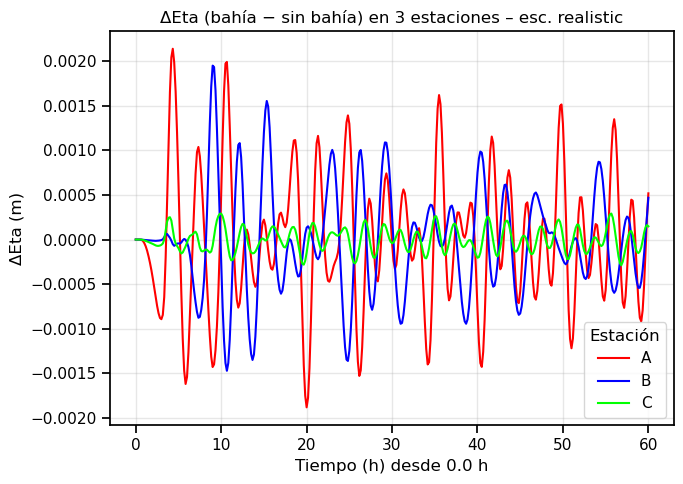

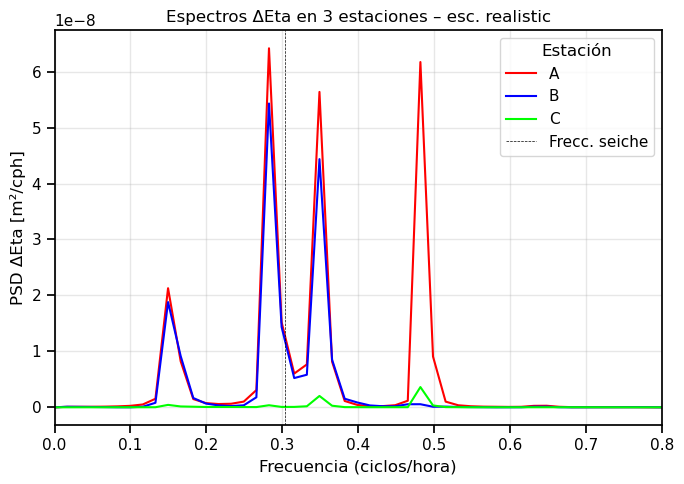

  -> Graficando ΔW (serie + espectro) para realistic


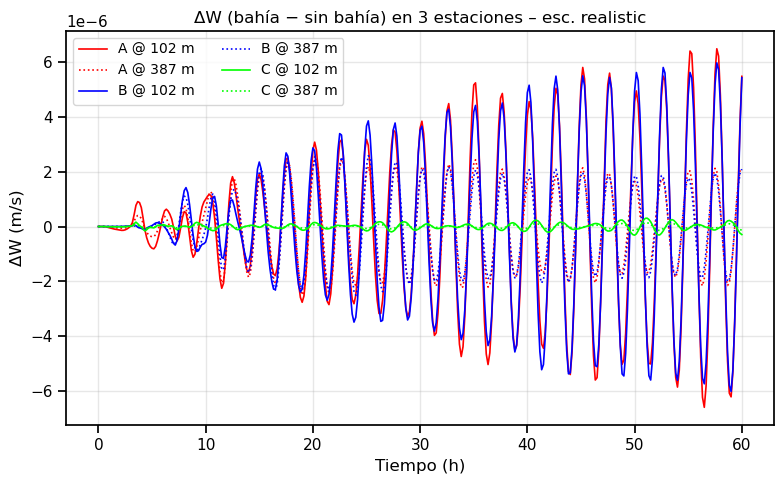

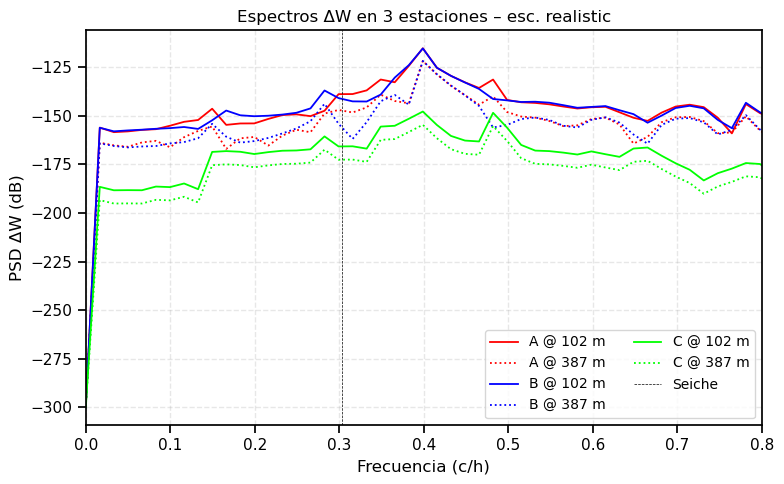

  -> Graficando Hovmöller ΔW para realistic


/var/folders/md/v_9w0p656250q6gw5wc707040000gn/T/ipykernel_37629/3304219858.py:142: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


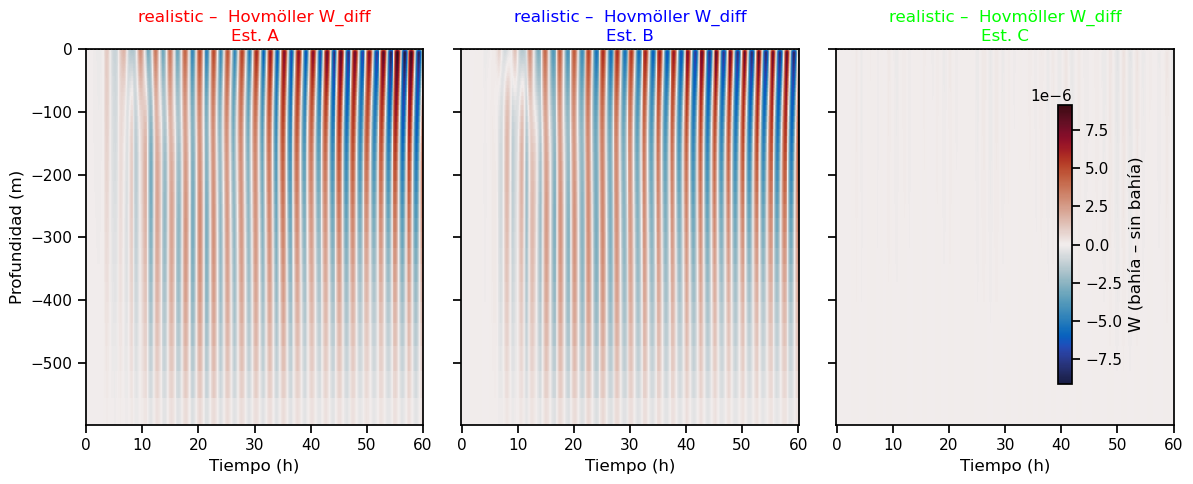


=== Procesando escenario: linear ===
  -> Graficando ΔEta (serie + espectro) para linear


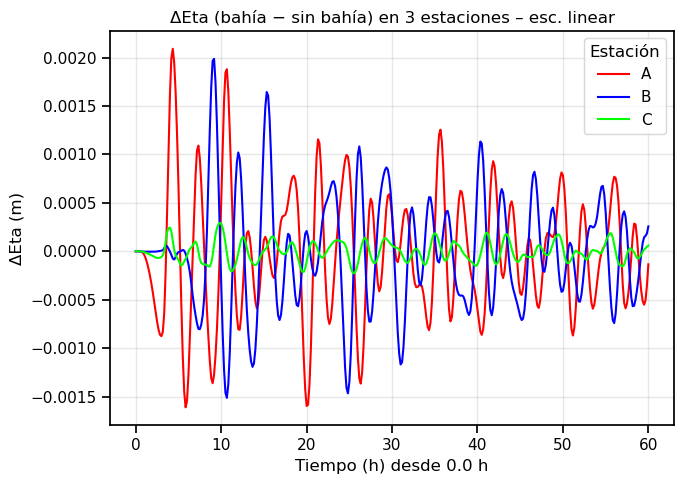

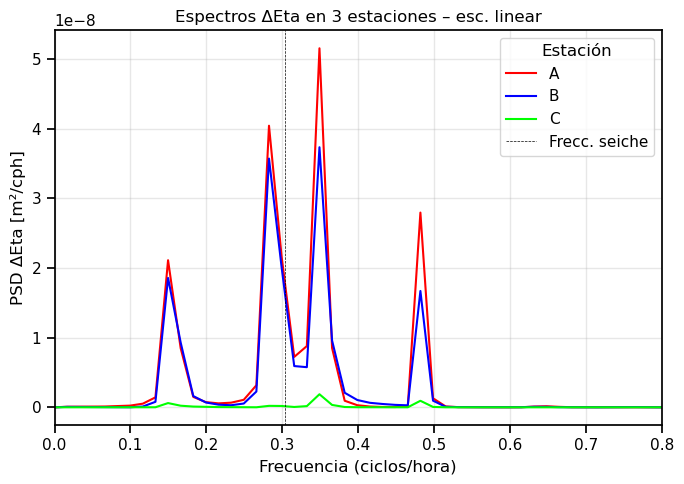

  -> Graficando ΔW (serie + espectro) para linear


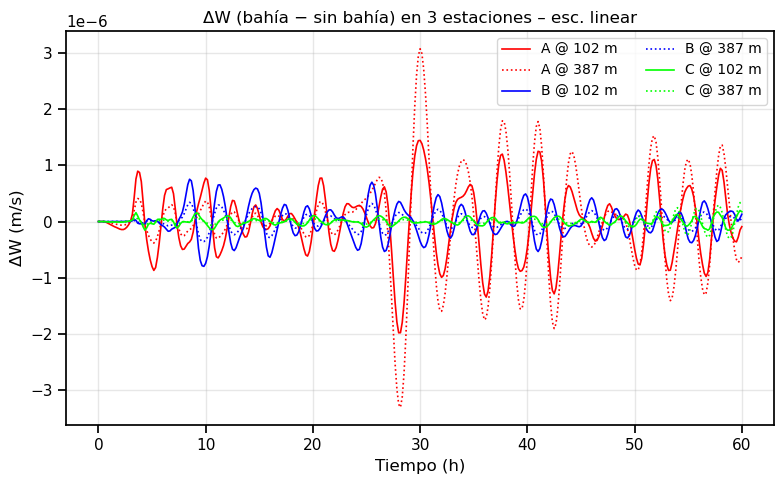

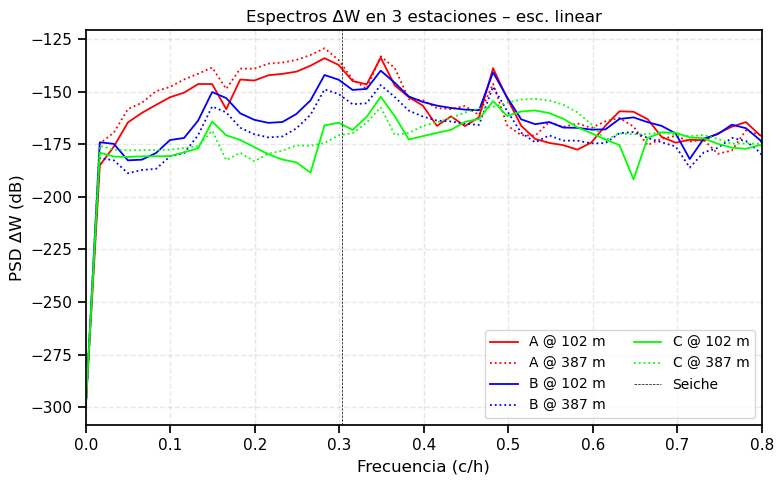

  -> Graficando Hovmöller ΔW para linear


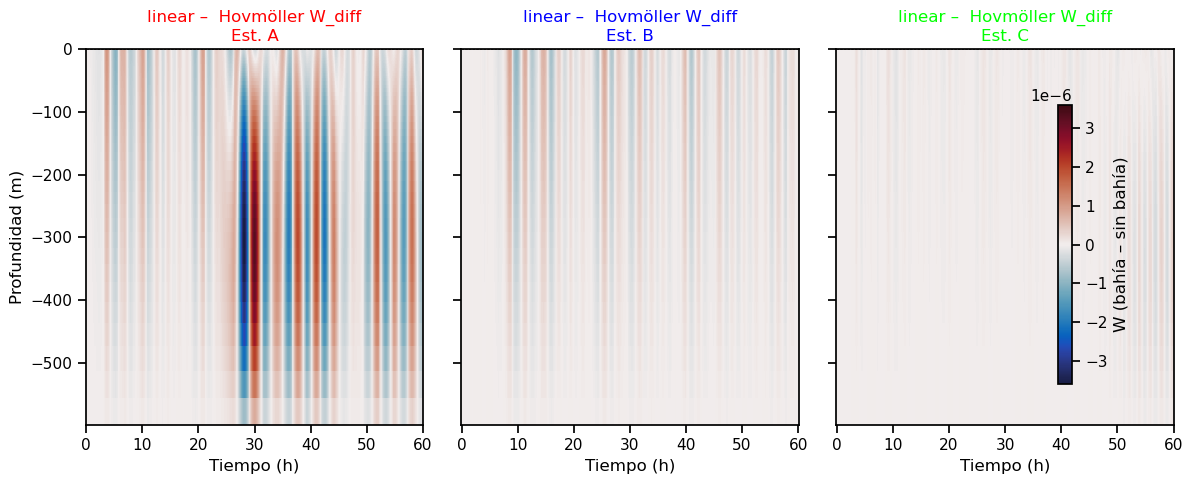


=== Procesando escenario: 2layer ===
  -> Graficando ΔEta (serie + espectro) para 2layer


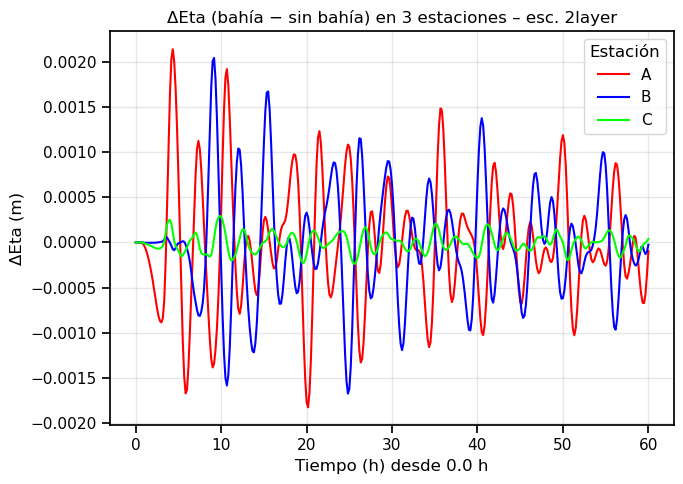

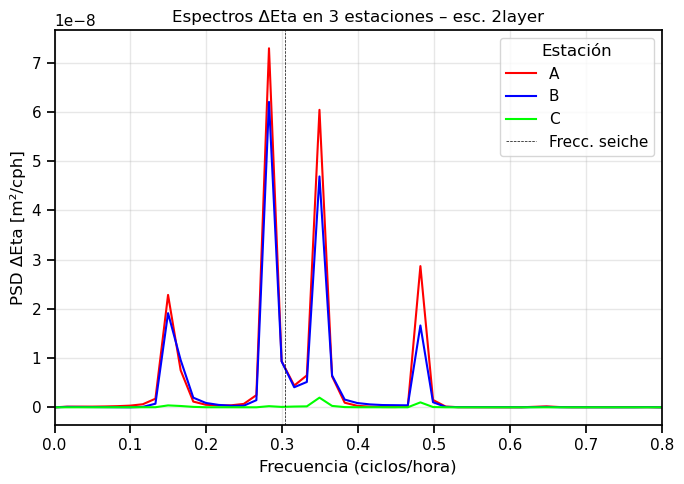

  -> Graficando ΔW (serie + espectro) para 2layer


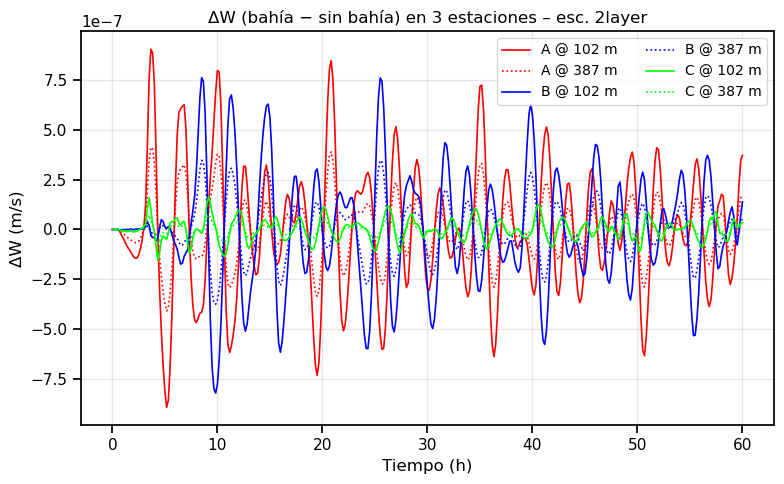

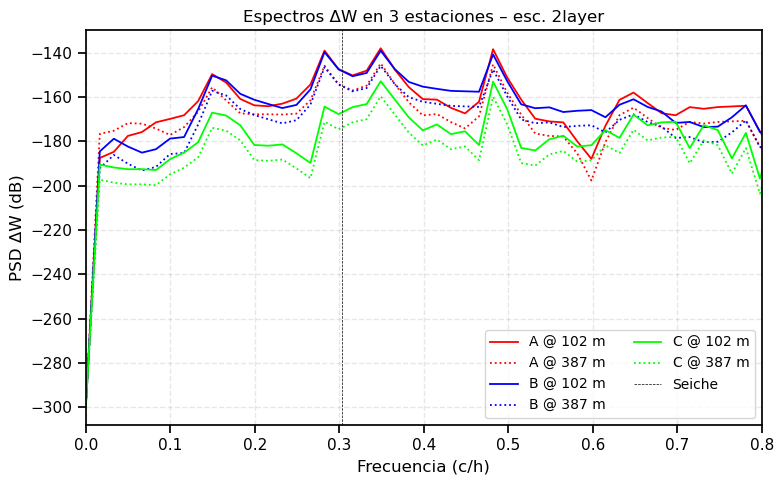

  -> Graficando Hovmöller ΔW para 2layer


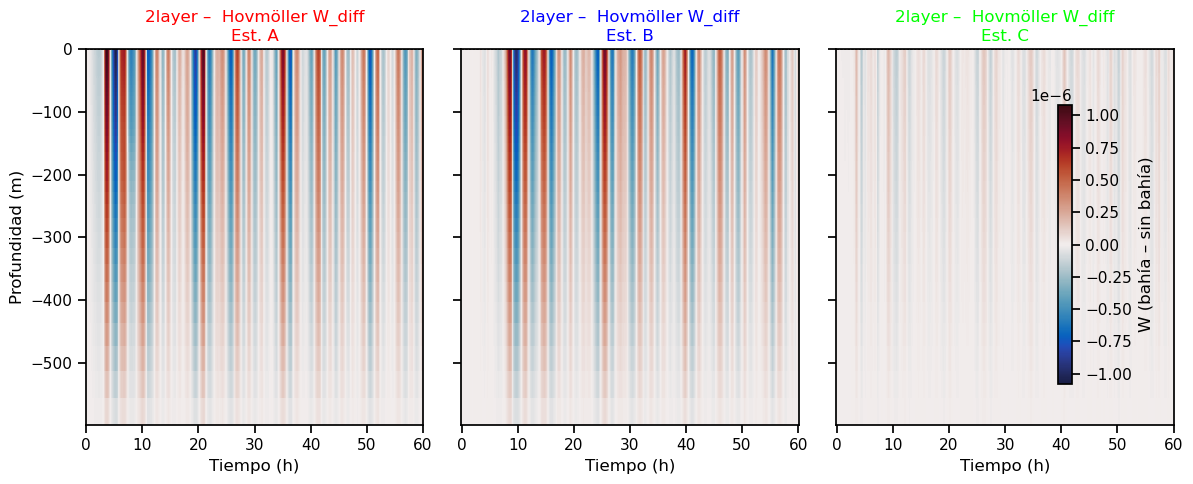


=== Comparando cada estación entre los 3 escenarios ===

--- Estación A ---


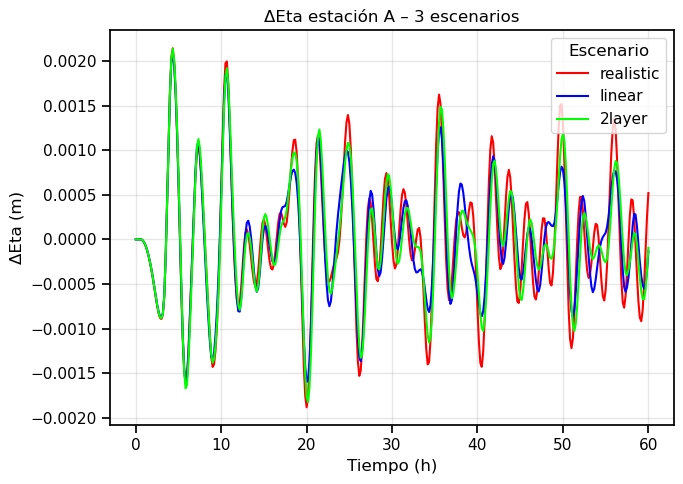

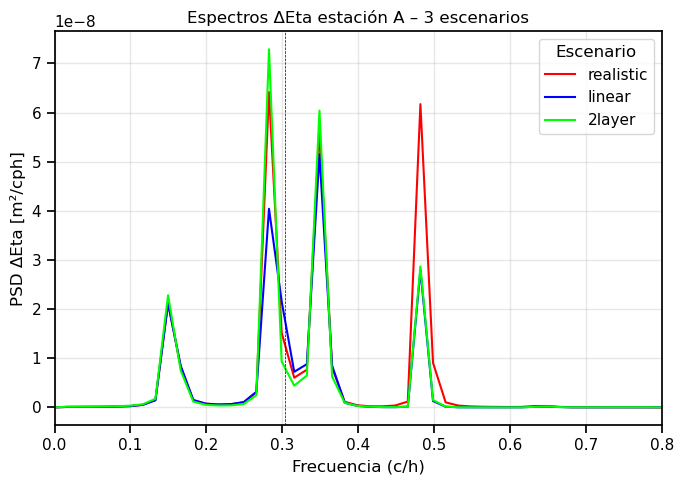

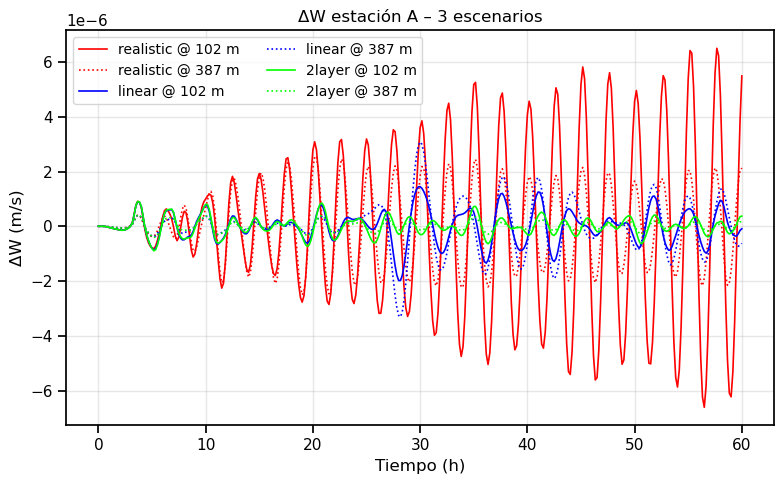

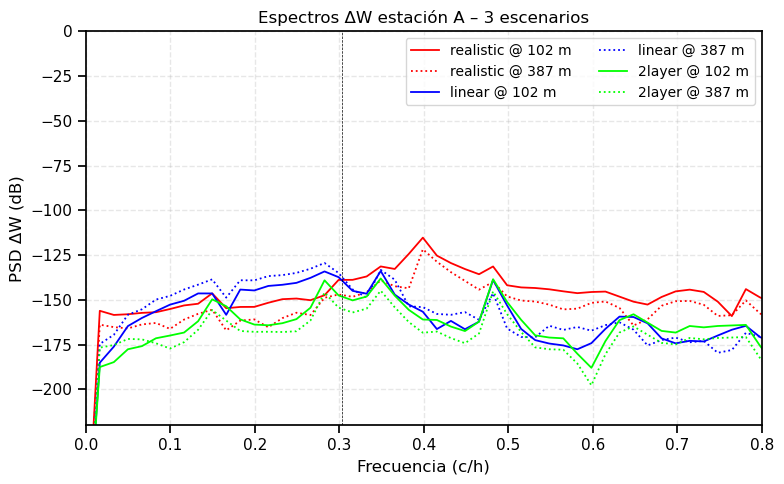


--- Estación B ---


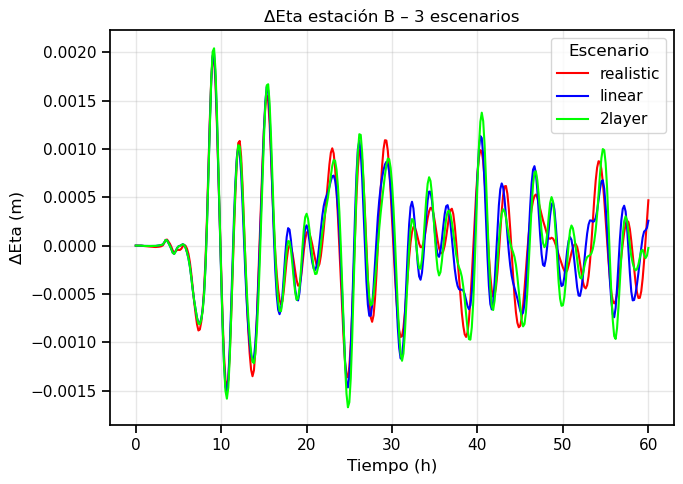

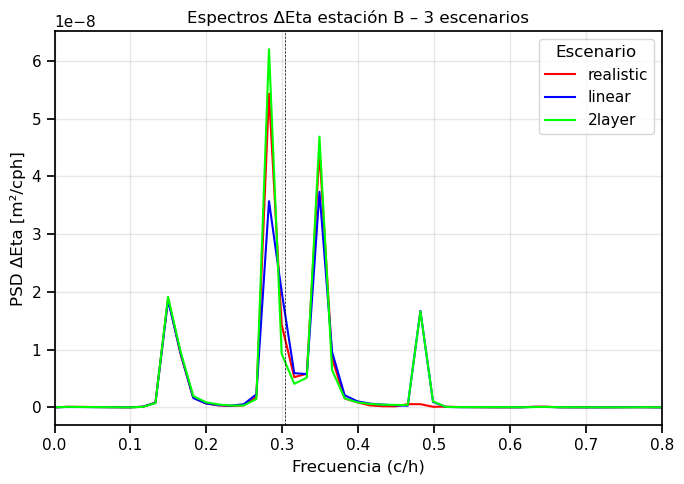

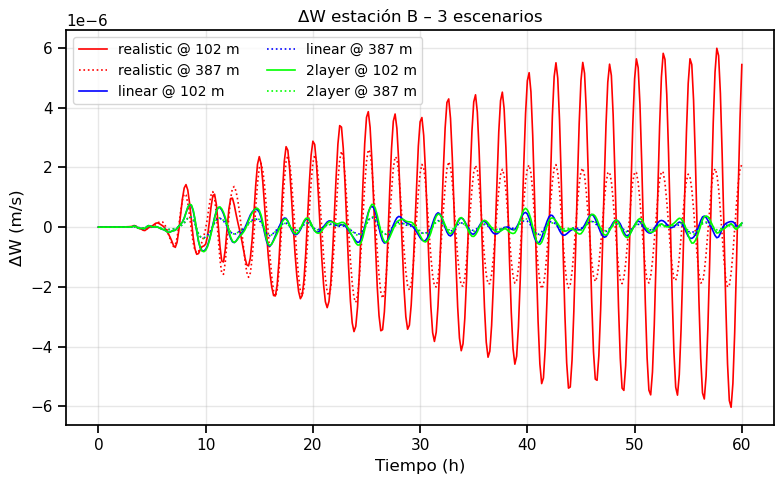

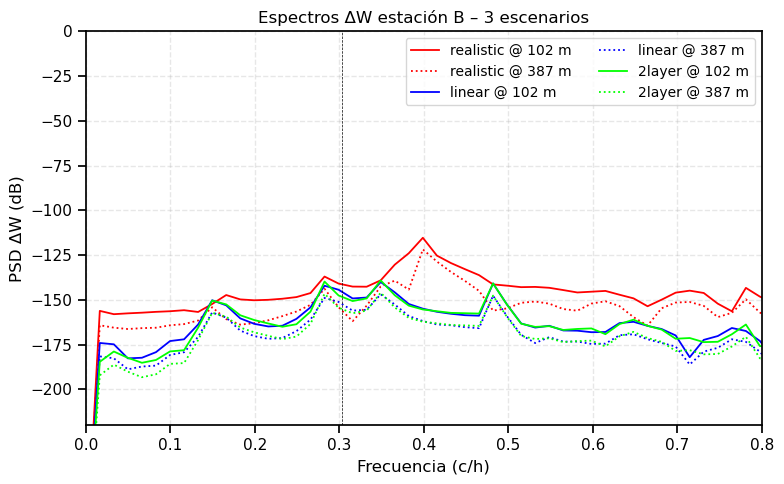


--- Estación C ---


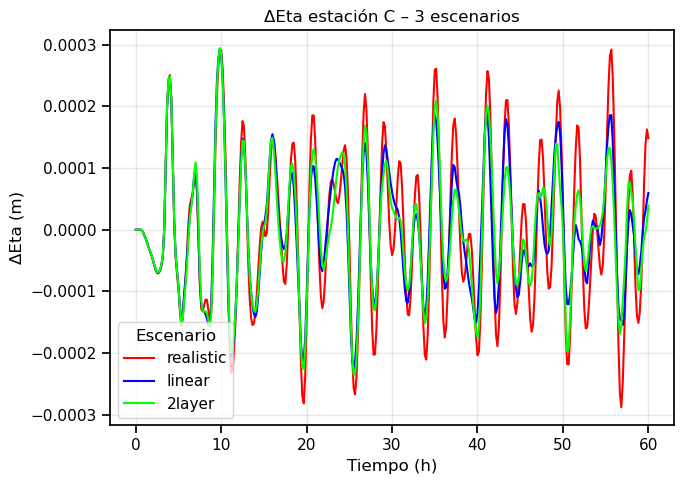

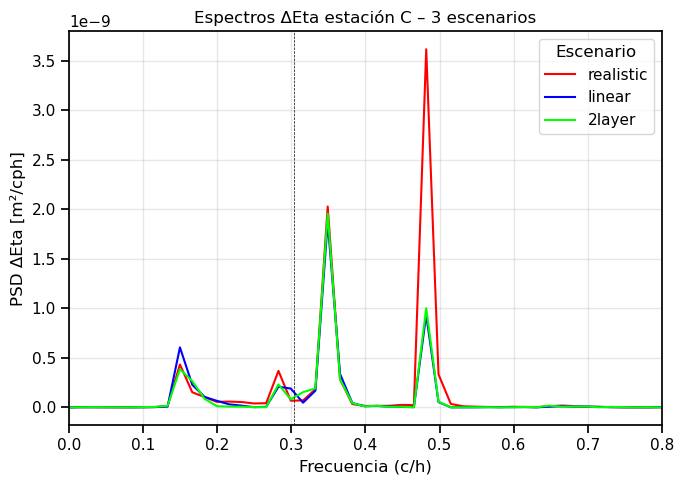

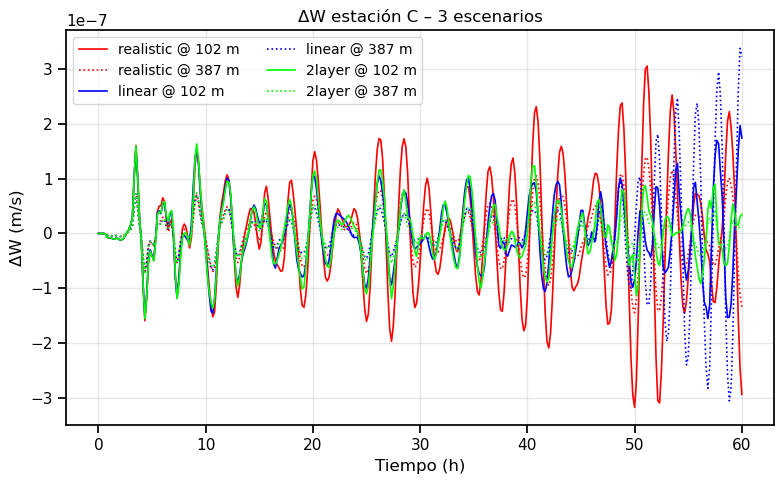

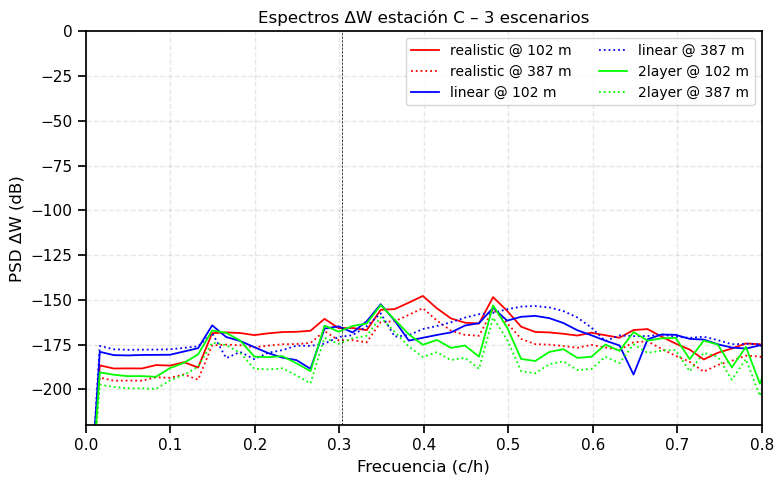

In [17]:
# =============================================================================
# Imports y definición de rutas/escenarios/estaciones
# =============================================================================
import os
import gc
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import cmocean as cmo
from scipy.signal import detrend
import MITgcmutils as MIT

# Rutas base: ajústalas a tu sistema
base_main = Path("/Volumes/Esteban_SSD/Maestría/MITgcm/verification")
scenarios = {
    'realistic': base_main / 'BayIW_Rectan',
    'linear'   : base_main / 'BayIW_Rectan_linear',
    '2layer'   : base_main / 'BayIW_Rectan_2layer',
}

# Definimos las 3 estaciones (i, j, etiqueta, color)
# Supongamos que ya calculaste i_centro, j_centro y radio previamente:
# Por ejemplo:

ny,nx = 320,277
i_centro = nx//2
j_centro = 245
radio    = 100
iA,jA = i_centro-radio, j_centro
iB,jB = i_centro+radio, j_centro
iC,jC = i_centro, j_centro-radio


stations = [
    (iA, jA, 'A', 'red'),
    (iB, jB, 'B', 'blue'),
    (iC, jC, 'C', 'lime'),
]

# Carpeta para cachear datos intermedios (asegúrate de que exista o créala)
cache_dir = Path("cache")
cache_dir.mkdir(exist_ok=True)

# =============================================================================
# Función de carga de datos MITgcm (tal como antes)
# =============================================================================
def cargar_datos_mitgcm(outdir_bay: Path, outdir_nobay: Path,
                        use_wildcard: bool = False):
    """Carga archivos netCDF (bay / nobay) y devuelve un diccionario."""
    pattern = 'state.*.t*.nc' if use_wildcard else 'state.0000002880.t*.nc'

    nc_bay   = MIT.mnc_files(str(outdir_bay   / pattern))
    gr_bay   = MIT.mnc_files(str(outdir_bay   / 'grid.t*.nc'))
    nc_nobay = MIT.mnc_files(str(outdir_nobay / pattern))

    time = nc_bay.variables['T'][:]          # segundos
    return {
        'nc_bay': nc_bay,
        'nc_nobay': nc_nobay,
        'gr_bay': gr_bay,
        'time': time
    }

# =============================================================================
# HOVMÖLLER MULTISTATION (tal como antes)
# =============================================================================
def hovmoller_diff_multistation(
    nc_bay,
    nc_nobay,
    gr,
    stations: list,
    varname: str = 'W',
    hours_offset: float = 0.0,
    cmap = cmo.cm.balance,
    vmin: float = None,
    vmax: float = None,
    title_prefix: str = ''
):
    """
    Dibuja diagramas de Hovmöller de la diferencia (bahía – sin bahía)
    para múltiples estaciones (en paralelo). Se asume que ya está todo cargado
    en nc_bay/nc_nobay/gr y solo graficamos.
    """

    # 1) Tiempo recortado
    t_all = nc_bay.variables['T'][:] / 3600.0   # en horas
    if hours_offset > 0:
        idx0 = np.where(t_all >= hours_offset)[0]
        idx0 = idx0[0] if idx0.size > 0 else 0
    else:
        idx0 = 0
    t = t_all[idx0:]  # tiempo recortado

    # 2) Profundidades una sola vez
    RC = gr.variables['RC'][:]  # array 1D de profundidades negativas

    # 3) Calcular vmin/vmax común
    if (vmin is None) or (vmax is None):
        max_abs = 0.0
        for (i_st, j_st, label, color) in stations:
            data_bay   = nc_bay.variables[varname][:, :, j_st, i_st]
            data_nobay = nc_nobay.variables[varname][:, :, j_st, i_st]
            diff_full  = data_bay - data_nobay
            diff_cut   = diff_full[idx0:, :]
            m = np.nanmax(np.abs(diff_cut))
            if m > max_abs:
                max_abs = m
        vmin = -max_abs
        vmax =  max_abs

    # 4) Crear figura con un sub‐plot por estación
    n = len(stations)
    fig, axes = plt.subplots(nrows=1, ncols=n, figsize=(4*n, 5), sharey=True)
    if n == 1:
        axes = [axes]

    for ax, (i_st, j_st, label, color) in zip(axes, stations):
        data_bay   = nc_bay.variables[varname][:, :, j_st, i_st].astype(float)
        data_nobay = nc_nobay.variables[varname][:, :, j_st, i_st].astype(float)
        diff_full  = data_bay - data_nobay
        diff_cut   = diff_full[idx0:, :]

        pcm = ax.pcolormesh(
            t,
            RC,
            diff_cut.T,
            cmap=cmap,
            vmin=vmin, vmax=vmax,
            shading='auto'
        )
        ax.set_title(f"{title_prefix} Hovmöller {varname}_diff\nEst. {label}", color=color)
        ax.set_xlabel("Tiempo (h)")
        if ax is axes[0]:
            ax.set_ylabel("Profundidad (m)")
        #ax.invert_yaxis()
        ax.axhline(0.0, color='k', linestyle='--', linewidth=0.5)

    cbar = fig.colorbar(pcm, ax=axes, orientation='vertical', fraction=0.015, pad=0.02)
    cbar.set_label(f"{varname} (bahía – sin bahía)")

    plt.tight_layout()
    plt.show()
    return fig, axes

# =============================================================================
# ============= Etapa A: Procesar cada ESCENARIO por separado ===============
# =============================================================================

# Opciones de recorte en tiempo (en horas) y profundidades en metros
tmin_horas_global = 0.0
depth_levels = [100, 400]  # en metros

for esc_name, esc_path in scenarios.items():
    print(f"\n=== Procesando escenario: {esc_name} ===")

    # 1) Cargar NETCDF de este escenario
    bay_dir   = esc_path / 'run_expand'       / 'mnc_00*'
    nobay_dir = esc_path / 'run_expand_nobay' / 'mnc_00*'
    datos = cargar_datos_mitgcm(bay_dir, nobay_dir, use_wildcard=True)

    nc_bay   = datos['nc_bay']
    nc_nobay = datos['nc_nobay']
    gr       = datos['gr_bay']
    time_vec = datos['time']

    # --- 1.a) Graficar ΔEta y su espectro para las 3 estaciones ---
    print(f"  -> Graficando ΔEta (serie + espectro) para {esc_name}")
    t = np.array(time_vec, dtype=float)
    tmin_s = tmin_horas_global * 3600.0
    idx0   = np.where(t >= tmin_s)[0][0] if np.any(t >= tmin_s) else 0
    tcut_eta = t[idx0:] / 3600.0

    # Figura serie ΔEta (3 estaciones)
    plt.figure(figsize=(7, 5))
    espectros_eta = {}
    for (i_st, j_st, label, color) in stations:
        eta_bay   = np.array(nc_bay.variables['Eta'][:, j_st, i_st], dtype=float)
        eta_nobay = np.array(nc_nobay.variables['Eta'][:, j_st, i_st], dtype=float)
        eta_diff  = eta_bay[idx0:] - eta_nobay[idx0:]
        plt.plot(
            tcut_eta,
            eta_diff,
            label=f"{label}",
            color=color
        )
        # FFT y PSD
        eta_dt = detrend(eta_diff)
        dt     = (t[idx0+1] - t[idx0]) if len(t[idx0:])>1 else 1.0
        N      = len(eta_dt)
        freqs  = np.fft.rfftfreq(N, d=dt)
        PSD    = (np.abs(np.fft.rfft(eta_dt))**2) / N**2
        espectros_eta[label] = (freqs * 3600.0, PSD)

        # Guardar en cache: tcut_eta y eta_diff, freqs y PSD
        cache_sub = cache_dir / esc_name
        cache_sub.mkdir(exist_ok=True)
        np.save(
            cache_sub / f"station_{label}_eta.npy",
            {
                "tcut_eta": tcut_eta,
                "eta_diff": eta_diff,
                "freq_eta": freqs * 3600.0,
                "PSD_eta": PSD
            }
        )

    plt.xlabel(f"Tiempo (h) desde {tmin_horas_global} h")
    plt.ylabel("ΔEta (m)")
    plt.title(f"ΔEta (bahía − sin bahía) en 3 estaciones – esc. {esc_name}")
    plt.legend(title="Estación")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Figura espectros ΔEta (3 estaciones)
    plt.figure(figsize=(7, 5))
    for (label, color) in [(s[2], s[3]) for s in stations]:
        f_eta, P_eta = espectros_eta[label]
        plt.plot(
            f_eta,
            P_eta,
            label=f"{label}",
            color=color
        )
    plt.xlim(0, 0.8)
    plt.axvline(0.303356, color='k', linestyle='--', linewidth=0.5,
                label='Frecc. seiche')
    plt.xlabel("Frecuencia (ciclos/hora)")
    plt.ylabel("PSD ΔEta [m²/cph]")
    plt.title(f"Espectros ΔEta en 3 estaciones – esc. {esc_name}")
    plt.legend(title="Estación")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # --- 1.b) Graficar ΔW (dos profundidades) y su espectro para las 3 estaciones ---
    print(f"  -> Graficando ΔW (serie + espectro) para {esc_name}")
    # Precalcular índices verticales para ~100 y ~400 m
    z_vals = np.array(nc_bay.variables['Z'][:], dtype=float)
    idx100 = int(np.argmin(np.abs(z_vals + 100.0)))
    idx400 = int(np.argmin(np.abs(z_vals + 400.0)))
    dep_idx = [idx100, idx400]
    perfiles = {idx100: "-", idx400: ":"}

    tcut_w = t[idx0:] / 3600.0
    espectros_w = {}

    # Figura ΔW (3 estaciones × 2 profundidades)
    plt.figure(figsize=(8, 5))
    for (i_st, j_st, label, color) in stations:
        for k in dep_idx:
            w_b   = np.array(nc_bay.variables['W'][:, k, j_st, i_st], dtype=float)
            w_n   = np.array(nc_nobay.variables['W'][:, k, j_st, i_st], dtype=float)
            w_diff = w_b[idx0:] - w_n[idx0:]
            plt.plot(
                tcut_w,
                w_diff,
                color=color,
                linestyle=perfiles[k],
                linewidth=1.2,
                label=f"{label} @ {abs(z_vals[k]):.0f} m"
            )
            # FFT y PSD
            w_dt = detrend(w_diff)
            dt   = (t[idx0+1] - t[idx0]) if len(t[idx0:])>1 else 1.0
            N    = len(w_dt)
            freqs= np.fft.rfftfreq(N, d=dt)
            PSD  = (np.abs(np.fft.rfft(w_dt))**2) / N**2
            espectros_w[(label, k)] = (freqs * 3600.0, PSD)

            # Guardar en cache: tcut_w y w_diff, freqs y PSD
            cache_sub = cache_dir / esc_name
            cache_sub.mkdir(exist_ok=True)
            np.save(
                cache_sub / f"station_{label}_w_k{k}.npy",
                {
                    "tcut_w": tcut_w,
                    "w_diff": w_diff,
                    "freq_w": freqs * 3600.0,
                    "PSD_w": PSD
                }
            )

    plt.xlabel("Tiempo (h)")
    plt.ylabel("ΔW (m/s)")
    plt.title(f"ΔW (bahía − sin bahía) en 3 estaciones – esc. {esc_name}")
    plt.grid(alpha=0.3)
    plt.legend(fontsize="small", ncol=2)
    plt.tight_layout()
    plt.show()

    # Figura espectros ΔW en dB (3 estaciones × 2 profundidades)
    plt.figure(figsize=(8, 5))
    for (i_st, j_st, label, color) in stations:
        for k in dep_idx:
            f_w, P_w = espectros_w[(label, k)]
            P_w_dB   = 10.0 * np.log10(P_w + 1e-30)
            plt.plot(
                f_w,
                P_w_dB,
                color=color,
                linestyle=perfiles[k],
                linewidth=1.3,
                label=f"{label} @ {abs(z_vals[k]):.0f} m"
            )
    plt.xlim(0, 0.8)
    plt.axvline(0.303356, linestyle='--', color='k', linewidth=0.5, label='Seiche')
    plt.xlabel("Frecuencia (c/h)")
    plt.ylabel("PSD ΔW (dB)")
    plt.title(f"Espectros ΔW en 3 estaciones – esc. {esc_name}")
    plt.grid(alpha=0.3, which='both', linestyle='--')
    plt.legend(fontsize="small", ncol=2)
    plt.tight_layout()
    plt.show()

    # --- 1.c) Hovmöller ΔW para las 3 estaciones (por escenario) ---
    print(f"  -> Graficando Hovmöller ΔW para {esc_name}")
    hovmoller_diff_multistation(
        nc_bay       = nc_bay,
        nc_nobay     = nc_nobay,
        gr           = gr,
        stations     = stations,
        varname      = 'W',
        hours_offset = tmin_horas_global,
        cmap         = cmo.cm.balance,
        vmin         = None,
        vmax         = None,
        title_prefix = f"{esc_name} – "
    )

    # 2) Cerrar y eliminar objetos NetCDF para no agotar descriptores de archivo
    try:
        nc_bay.close()
    except Exception:
        pass
    try:
        nc_nobay.close()
    except Exception:
        pass
    try:
        gr.close()
    except Exception:
        pass

    del nc_bay, nc_nobay, gr, datos
    gc.collect()


# =============================================================================
# ============= Etapa B: Comparar cada ESTACIÓN en los 3 escenarios ============
# =============================================================================

print("\n=== Comparando cada estación entre los 3 escenarios ===")
color_esc = {'realistic':'red', 'linear':'blue', '2layer':'lime'}

for (i_st, j_st, label, _) in stations:
    print(f"\n--- Estación {label} ---")

    # 5.a) ΔEta: serie comparativa (3 escenarios)
    plt.figure(figsize=(7, 5))
    espectros_cmp_eta = {}
    for esc_name in scenarios.keys():
        # Leer del cache
        archivo = cache_dir / esc_name / f"station_{label}_eta.npy"
        data_arr = np.load(archivo, allow_pickle=True).item()
        tcut_eta = data_arr["tcut_eta"]
        eta_diff = data_arr["eta_diff"]
        freq_eta = data_arr["freq_eta"]
        PSD_eta  = data_arr["PSD_eta"]

        color = color_esc[esc_name]
        plt.plot(
            tcut_eta,
            eta_diff,
            label=f"{esc_name}",
            color=color
        )
        espectros_cmp_eta[esc_name] = (freq_eta, PSD_eta)

    plt.xlabel("Tiempo (h)")
    plt.ylabel("ΔEta (m)")
    plt.title(f"ΔEta estación {label} – 3 escenarios")
    plt.legend(title="Escenario")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # 5.a.2) Espectros ΔEta (3 escenarios)
    plt.figure(figsize=(7, 5))
    for esc_name in scenarios.keys():
        freq_eta, PSD_eta = espectros_cmp_eta[esc_name]
        color = color_esc[esc_name]
        plt.plot(
            freq_eta,
            PSD_eta,
            label=f"{esc_name}",
            color=color
        )
    plt.xlim(0, 0.8)
    plt.axvline(0.303356, color='k', linestyle='--', linewidth=0.5)
    plt.xlabel("Frecuencia (c/h)")
    plt.ylabel("PSD ΔEta [m²/cph]")
    plt.title(f"Espectros ΔEta estación {label} – 3 escenarios")
    plt.legend(title="Escenario")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # 5.b) ΔW: serie comparativa (3 escenarios × 2 profundidades)
    plt.figure(figsize=(8, 5))
    espectros_cmp_w = {}
    for esc_name in scenarios.keys():
        # Leer del cache: 2 archivos, uno para k100 y otro para k400
        cache_sub = cache_dir / esc_name
        data100 = np.load(cache_sub / f"station_{label}_w_k{idx100}.npy", allow_pickle=True).item()
        data400 = np.load(cache_sub / f"station_{label}_w_k{idx400}.npy", allow_pickle=True).item()

        tcut_w  = data100["tcut_w"]  # mismo tcut para k100 y k400
        w_diff100 = data100["w_diff"]
        w_diff400 = data400["w_diff"]
        freq100   = data100["freq_w"]
        PSD100    = data100["PSD_w"]
        freq400   = data400["freq_w"]
        PSD400    = data400["PSD_w"]

        color = color_esc[esc_name]
        plt.plot(
            tcut_w,
            w_diff100,
            linestyle='-',
            color=color,
            linewidth=1.2,
            label=f"{esc_name} @ {abs(z_vals[idx100]):.0f} m"
        )
        plt.plot(
            tcut_w,
            w_diff400,
            linestyle=':',
            color=color,
            linewidth=1.2,
            label=f"{esc_name} @ {abs(z_vals[idx400]):.0f} m"
        )
        espectros_cmp_w[(esc_name, idx100)] = (freq100, PSD100)
        espectros_cmp_w[(esc_name, idx400)] = (freq400, PSD400)

    plt.xlabel("Tiempo (h)")
    plt.ylabel("ΔW (m/s)")
    plt.title(f"ΔW estación {label} – 3 escenarios")
    plt.grid(alpha=0.3)
    plt.legend(fontsize="small", ncol=2)
    plt.tight_layout()
    plt.show()

    # 5.b.2) Espectros ΔW en dB (3 escenarios)
    plt.figure(figsize=(8, 5))
    for esc_name in scenarios.keys():
        color = color_esc[esc_name]
        # k100
        freq100, PSD100 = espectros_cmp_w[(esc_name, idx100)]
        PSD100_dB = 10.0 * np.log10(PSD100 + 1e-30)
        plt.plot(
            freq100,
            PSD100_dB,
            linestyle='-',
            color=color,
            linewidth=1.3,
            label=f"{esc_name} @ {abs(z_vals[idx100]):.0f} m"
        )
        # k400
        freq400, PSD400 = espectros_cmp_w[(esc_name, idx400)]
        PSD400_dB = 10.0 * np.log10(PSD400 + 1e-30)
        plt.plot(
            freq400,
            PSD400_dB,
            linestyle=':',
            color=color,
            linewidth=1.3,
            label=f"{esc_name} @ {abs(z_vals[idx400]):.0f} m"
        )

    plt.xlim(0, 0.8)
    plt.axvline(0.303356, linestyle='--', color='k', linewidth=0.5)
    plt.xlabel("Frecuencia (c/h)")
    plt.ylabel("PSD ΔW (dB)")
    plt.title(f"Espectros ΔW estación {label} – 3 escenarios")
    plt.legend(fontsize="small", ncol=2)
    plt.grid(alpha=0.3, which='both', linestyle='--')
    plt.ylim(-220,0)
    plt.tight_layout()
    plt.show()



Procesando Escenario: realistic


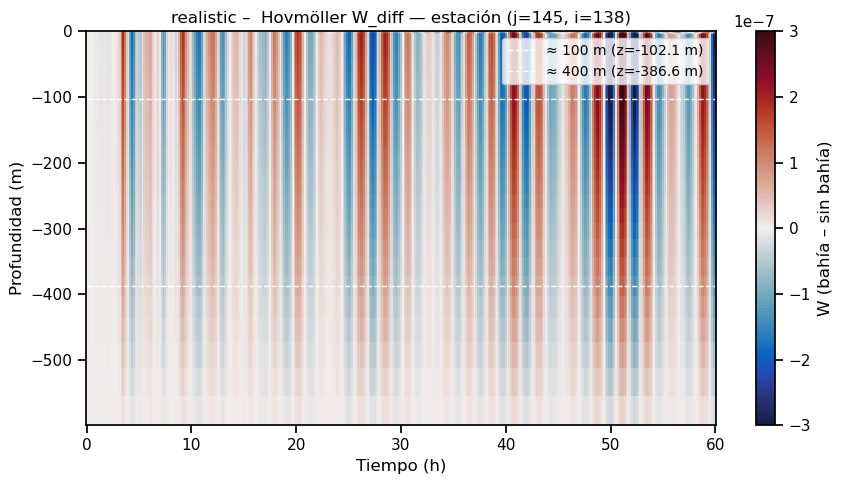


Procesando Escenario: linear


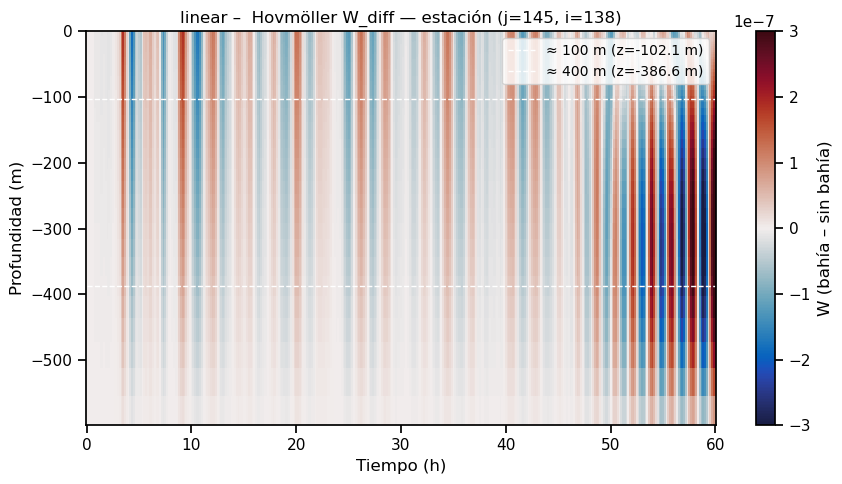


Procesando Escenario: 2layer


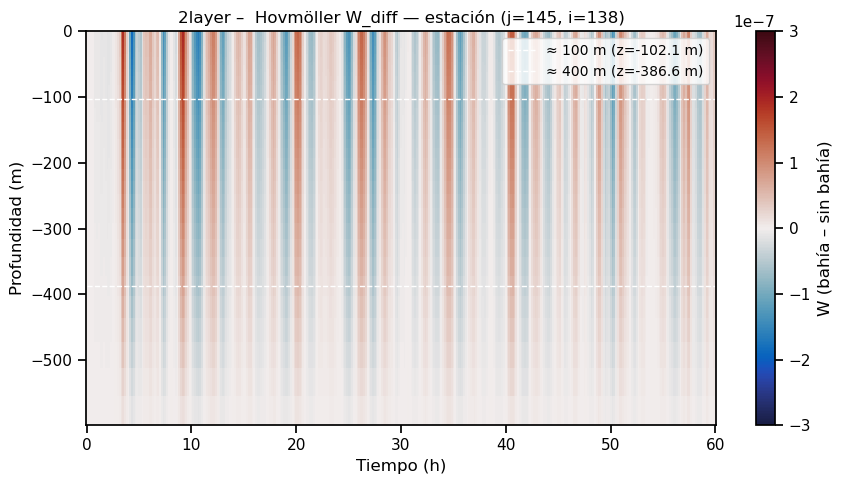

In [15]:
# Estación C: índices (iC, jC) y color/label
# Estación C: misma X central, pero 100 celdas más al norte, color verde lima
iC, jC = i_centro, j_centro - radio    # Reemplaza con los índices correctos para tu malla
station_C = (jC, iC)  # hovmoller_diff espera (j, i)
label_C = 'C'
color_C = 'lime'
# -------------------------------------------------------------------
# 3. Recorrer cada escenario y dibujar Hovmöller en estación C
# -------------------------------------------------------------------
for esc_name, esc_path in scenarios.items():
    print(f"\nProcesando Escenario: {esc_name}")

    # 3.a) Cargar archivo NetCDF correspondiente
    bay_dir   = esc_path / 'run_expand'       / 'mnc_00*'
    nobay_dir = esc_path / 'run_expand_nobay' / 'mnc_00*'
    datos = cargar_datos_mitgcm(bay_dir, nobay_dir, use_wildcard=True)

    nc_bay   = datos['nc_bay']
    nc_nobay = datos['nc_nobay']
    gr       = datos['gr_bay']

    # 3.b) Llamar a hovmoller_diff para estación C
    hovmoller_diff(
        nc_bay       = nc_bay,
        nc_nobay     = nc_nobay,
        gr           = gr,
        station      = station_C,
        varname      = 'W',
        hours_offset = 0.0,
        cmap         = cmo.cm.balance,
        vmin         = -3e-7,
        vmax         = 3e-7,
        title_prefix = f"{esc_name} – "
    )

    # 3.c) Cerrar y eliminar para no agotar descriptores
    try:
        nc_bay.close()
    except:
        pass
    try:
        nc_nobay.close()
    except:
        pass
    try:
        gr.close()
    except:
        pass

    del nc_bay, nc_nobay, gr, datos
    gc.collect()


Procesando Escenario: realistic


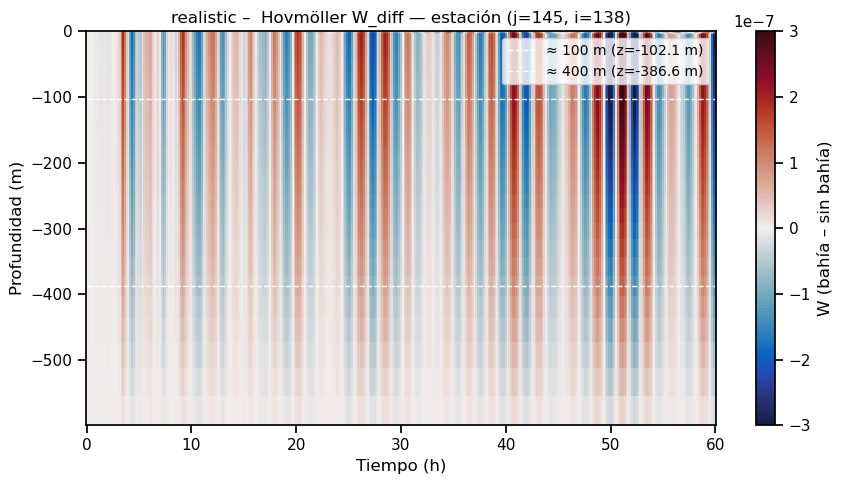


Procesando Escenario: linear


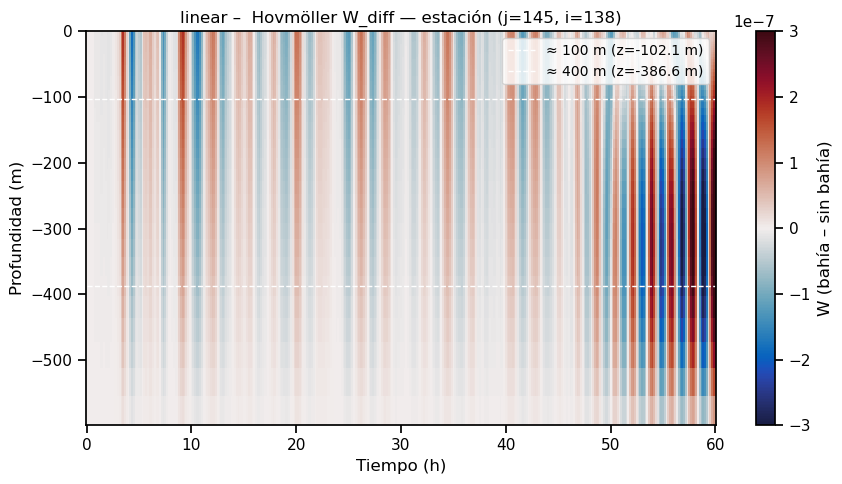


Procesando Escenario: 2layer


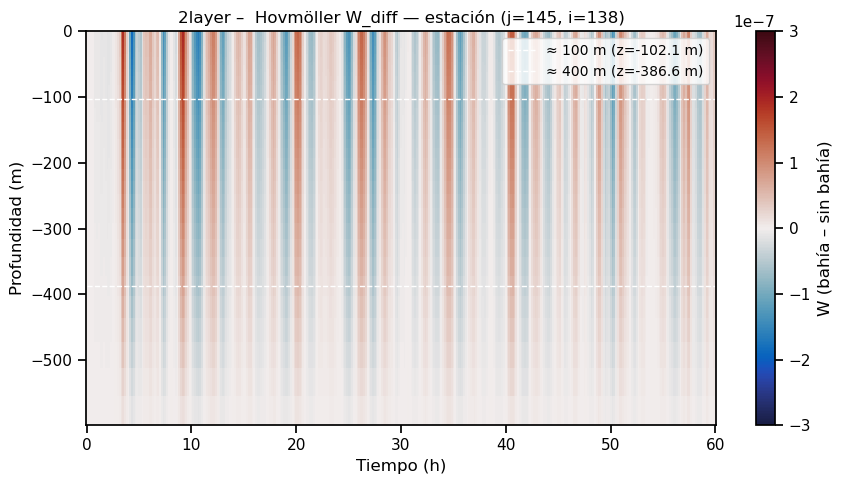

In [ ]:
# Estación C: índices (iC, jC) y color/label
# Estación C: misma X central, pero 100 celdas más al norte, color verde lima
iC, jC = i_centro, j_centro - radio    # Reemplaza con los índices correctos para tu malla
station_C = (jC, iC)  # hovmoller_diff espera (j, i)
label_C = 'C'
color_C = 'lime'
# -------------------------------------------------------------------
# 3. Recorrer cada escenario y dibujar Hovmöller en estación C
# -------------------------------------------------------------------
for esc_name, esc_path in scenarios.items():
    print(f"\nProcesando Escenario: {esc_name}")

    # 3.a) Cargar archivo NetCDF correspondiente
    bay_dir   = esc_path / 'run_expand'       / 'mnc_00*'
    nobay_dir = esc_path / 'run_expand_nobay' / 'mnc_00*'
    datos = cargar_datos_mitgcm(bay_dir, nobay_dir, use_wildcard=True)

    nc_bay   = datos['nc_bay']
    nc_nobay = datos['nc_nobay']
    gr       = datos['gr_bay']

    # 3.b) Llamar a hovmoller_diff para estación C
    hovmoller_diff(
        nc_bay       = nc_bay,
        nc_nobay     = nc_nobay,
        gr           = gr,
        station      = station_C,
        varname      = 'W',
        hours_offset = 0.0,
        cmap         = cmo.cm.balance,
        vmin         = -3e-7,
        vmax         = 3e-7,
        title_prefix = f"{esc_name} – "
    )

    # 3.c) Cerrar y eliminar para no agotar descriptores
    try:
        nc_bay.close()
    except:
        pass
    try:
        nc_nobay.close()
    except:
        pass
    try:
        gr.close()
    except:
        pass

    del nc_bay, nc_nobay, gr, datos
    gc.collect()

In [1]:
import MITgcmutils as MIT
from pathlib import Path
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
# Rutas base: ajusta a tu sistema
base_main = Path("/Volumes/Esteban_SSD/Maestría/MITgcm/verification")

scenarios = {
    'realistic': base_main / 'BayIW_Rectan',
    'linear'   : base_main / 'BayIW_Rectan_linear',
    '2layer'   : base_main / 'BayIW_Rectan_2layer',
    # añade más aquí si quieres
}
bay_dir   = scenarios['linear'] / 'run_expand'       / 'mnc_*'
nobay_dir = scenarios['linear'] / 'run_expand_nobay' / 'mnc_*'
grid_bay = MIT.mnc_files(str(scenarios['linear'] / bay_dir / 'grid.t*.nc'))
grid_nobay = MIT.mnc_files(str(scenarios['linear'] / nobay_dir / 'grid.t*.nc'))

In [2]:
depth_bay= grid_bay.variables['Depth'][:]  # 
depth_nobay= grid_nobay.variables['Depth'][:]  # 

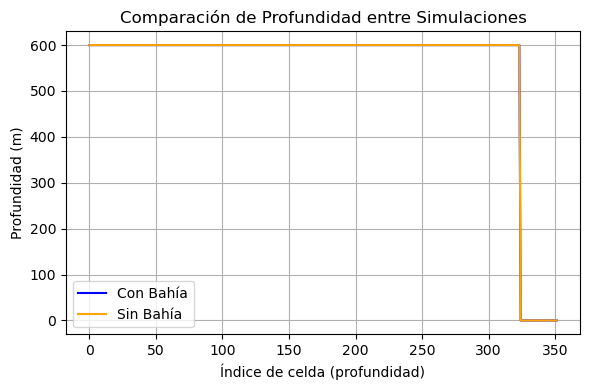

In [3]:
#Graficar comparación de profundidad
plt.figure(figsize=(6,4))
plt.plot(depth_bay[:,0], label='Con Bahía', color='blue')
plt.plot(depth_nobay[:,0], label='Sin Bahía', color='orange')
plt.xlabel('Índice de celda (profundidad)')
plt.ylabel('Profundidad (m)')
plt.title('Comparación de Profundidad entre Simulaciones')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()